# Model Training Results: Pairwise Amino Acid Classification

This notebook analyzes model training results from 190 pairwise amino acid comparisons.
We compare different model architectures and evaluate the impact of dwell time features.

In [1]:
import warnings

import plotnine as p9
import polars as pl
from great_tables import GT

warnings.filterwarnings("ignore")

# Set plot aesthetics
p9.theme_set(p9.theme_minimal() + p9.theme(figure_size=(12, 6)))

## Load Data

In [2]:
# Load the pairwise architecture comparison data
data_path = "/scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/metrics/comparison/aggregate/pairwise_architecture_comparison.tsv"

df = pl.read_csv(data_path, separator="\t")

print(f"Total rows: {len(df)}")
print(f"Total pairs: {df['pair'].n_unique()}")
print(f"Architectures: {df['architecture'].unique().to_list()}")
print(f"\nColumns: {df.columns}")

Total rows: 1140
Total pairs: 190
Architectures: ['ConvLSTMDwell', 'TransformerDwell', 'ConvLSTMBase', 'ConvOnly', 'ResNetDwell', 'TCNDwell']

Columns: ['pair', 'architecture', 'n_samples', 'accuracy_mean', 'accuracy_std', 'f1_mean', 'f1_std', 'precision_mean', 'precision_std', 'recall_mean', 'recall_std']


In [3]:
# Show first few rows
df.head(10)

pair,architecture,n_samples,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
str,str,i64,f64,str,f64,str,f64,str,f64,str
"""Ala_Arg""","""TCNDwell""",1,0.919,null,0.9521,null,0.9389,null,0.9657,null
"""Ala_Arg""","""ConvOnly""",1,0.8905,null,0.9341,null,0.9368,null,0.9314,null
"""Ala_Arg""","""ResNetDwell""",1,0.881,null,0.9284,null,0.931,null,0.9257,null
"""Ala_Arg""","""ConvLSTMBase""",1,0.8571,null,0.9112,null,0.9448,null,0.88,null
"""Ala_Arg""","""ConvLSTMDwell""",1,0.8524,null,0.9091,null,0.9337,null,0.8857,null
"""Ala_Arg""","""TransformerDwell""",1,0.8333,null,0.9091,null,0.8333,null,1.0,null
"""Ala_Asn""","""TransformerDwell""",1,0.801,null,0.8895,null,0.801,null,1.0,null
"""Ala_Asn""","""ConvOnly""",1,0.801,null,0.8848,null,0.8249,null,0.9542,null
"""Ala_Asn""","""ResNetDwell""",1,0.7906,null,0.883,null,0.7989,null,0.9869,null


## Summary Statistics

In [4]:
# Overall performance by architecture
# Check which metrics are available in the dataframe
available_metrics = []
metric_names = []

if "accuracy_mean" in df.columns:
    available_metrics.append(pl.col("accuracy_mean").mean().alias("avg_accuracy"))
    available_metrics.append(pl.col("accuracy_mean").std().alias("std_accuracy"))
    metric_names.extend(["accuracy"])

if "f1_mean" in df.columns:
    available_metrics.append(pl.col("f1_mean").mean().alias("avg_f1"))
    available_metrics.append(pl.col("f1_mean").std().alias("std_f1"))
    metric_names.extend(["f1"])

if "auroc_mean" in df.columns:
    available_metrics.append(pl.col("auroc_mean").mean().alias("avg_auroc"))
    available_metrics.append(pl.col("auroc_mean").std().alias("std_auroc"))
    metric_names.extend(["auroc"])

if "auprc_mean" in df.columns:
    available_metrics.append(pl.col("auprc_mean").mean().alias("avg_auprc"))
    available_metrics.append(pl.col("auprc_mean").std().alias("std_auprc"))
    metric_names.extend(["auprc"])

available_metrics.append(pl.count().alias("n_pairs"))

# Determine sort key (prefer f1, then accuracy)
sort_key = "avg_f1" if "f1_mean" in df.columns else "avg_accuracy"

summary = (
    df.group_by("architecture")
    .agg(available_metrics)
    .sort(sort_key, descending=True)
)

print("\nOverall Performance by Architecture (averaged across all pairs):")
print(f"Available metrics: {', '.join(metric_names)}")

(
    GT(summary)
    .tab_header(
        title="Overall Performance by Architecture",
        subtitle="Averaged across all pairs"
    )
    .fmt_number(
        columns=["avg_accuracy", "std_accuracy", "avg_f1", "std_f1"],
        decimals=4
    )
    .data_color(
        columns=["avg_f1"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.5, 1.0]
    )
)


Overall Performance by Architecture (averaged across all pairs):
Available metrics: accuracy, f1


GT(_tbl_data=shape: (6, 6)
┌──────────────────┬──────────────┬──────────────┬──────────┬──────────┬─────────┐
│ architecture     ┆ avg_accuracy ┆ std_accuracy ┆ avg_f1   ┆ std_f1   ┆ n_pairs │
│ ---              ┆ ---          ┆ ---          ┆ ---      ┆ ---      ┆ ---     │
│ str              ┆ f64          ┆ f64          ┆ f64      ┆ f64      ┆ u32     │
╞══════════════════╪══════════════╪══════════════╪══════════╪══════════╪═════════╡
│ ConvOnly         ┆ 0.869213     ┆ 0.075177     ┆ 0.874176 ┆ 0.102924 ┆ 190     │
│ ResNetDwell      ┆ 0.858472     ┆ 0.076899     ┆ 0.866008 ┆ 0.104749 ┆ 190     │
│ TCNDwell         ┆ 0.856994     ┆ 0.07884      ┆ 0.865521 ┆ 0.102169 ┆ 190     │
│ ConvLSTMBase     ┆ 0.861168     ┆ 0.079697     ┆ 0.860351 ┆ 0.135423 ┆ 190     │
│ ConvLSTMDwell    ┆ 0.856734     ┆ 0.083966     ┆ 0.85449  ┆ 0.139661 ┆ 190     │
│ TransformerDwell ┆ 0.747777     ┆ 0.188043     ┆ 0.6      ┆ 0.420812 ┆ 190     │
└──────────────────┴──────────────┴──────────────┴──────────┴──────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x1476f77f83e0>, _boxhead=Boxhead([ColInfo(var='architecture', type=<ColInfoTypeEnum.default: 1>, column_label='architecture', column_align='left', column_width=None), ColInfo(var='avg_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='avg_accuracy', column_align='right', column_width=None), ColInfo(var='std_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='std_accuracy', column_align='right', column_width=None), ColInfo(var='avg_f1', type=<ColInfoTypeEnum.default: 1>, column_label='avg_f1', column_align='right', column_width=None), ColInfo(var='std_f1', type=<ColInfoTypeEnum.default: 1>, column_label='std_f1', column_align='right', column_width=None), ColInfo(var='n_pairs', type=<ColInfoTypeEnum.default: 1>, column_label='n_pairs', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1476f6d36de0>, _spanners=Spanners([]), _heading=Heading(title='Overall Performance by Architecture', subtitle='Averaged across all pairs', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1476f6d03080>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x14771b190170>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='avg_f1', rows=[0], mask=None), grpname=None, colname='avg_f1', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bb4546')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[1], mask=None), grpname=None, colname='avg_f1', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bd484a')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[2], mask=None), grpname=None, colname='avg_f1', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bd494a')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[3], mask=None), grpname=None, colname='avg_f1', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#be4b4c')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[4], mask=None), grpname=None, colname='avg_f1', rownum=4, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bf4d4e')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[5], mask

In [5]:
# Identify best and worst performing pairs
best_pairs = (
    df.sort("f1_mean", descending=True)
    .select(["pair", "architecture", "f1_mean", "accuracy_mean"])
    .head(10)
)
worst_pairs = (
    df.sort("f1_mean").select(["pair", "architecture", "f1_mean", "accuracy_mean"]).head(10)
)

print("\nTop 10 Best Performing Pairs:")
(
    GT(best_pairs)
    .tab_header(title="Top 10 Best Performing Pairs")
    .fmt_number(columns=["f1_mean", "accuracy_mean"], decimals=4)
    .data_color(
        columns=["f1_mean"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.5, 1.0]
    )
)

print("\nTop 10 Most Challenging Pairs:")
(
    GT(worst_pairs)
    .tab_header(title="Top 10 Most Challenging Pairs")
    .fmt_number(columns=["f1_mean", "accuracy_mean"], decimals=4)
    .data_color(
        columns=["f1_mean"],
        palette=["#a50f15", "#fee5d9"],
        domain=[0.0, 0.5]
    )
)


Top 10 Best Performing Pairs:

Top 10 Most Challenging Pairs:


GT(_tbl_data=shape: (10, 4)
┌─────────┬──────────────────┬─────────┬───────────────┐
│ pair    ┆ architecture     ┆ f1_mean ┆ accuracy_mean │
│ ---     ┆ ---              ┆ ---     ┆ ---           │
│ str     ┆ str              ┆ f64     ┆ f64           │
╞═════════╪══════════════════╪═════════╪═══════════════╡
│ Ala_Asp ┆ TransformerDwell ┆ 0.0     ┆ 0.0209        │
│ Arg_Asn ┆ TransformerDwell ┆ 0.0     ┆ 0.5321        │
│ Arg_Cys ┆ ConvLSTMBase     ┆ 0.0     ┆ 0.692         │
│ Arg_Cys ┆ TransformerDwell ┆ 0.0     ┆ 0.692         │
│ Asn_Cys ┆ TransformerDwell ┆ 0.0     ┆ 0.6621        │
│ Asn_Ser ┆ TransformerDwell ┆ 0.0     ┆ 0.0363        │
│ Asp_Cys ┆ ConvLSTMBase     ┆ 0.0     ┆ 0.959         │
│ Asp_Cys ┆ TransformerDwell ┆ 0.0     ┆ 0.959         │
│ Asp_Gln ┆ TransformerDwell ┆ 0.0     ┆ 0.5208        │
│ Asp_Gly ┆ TransformerDwell ┆ 0.0     ┆ 0.8454        │
└─────────┴──────────────────┴─────────┴───────────────┘, _body=<great_tables._gt_data.Body object at 0x1476f6d37f20>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='architecture', type=<ColInfoTypeEnum.default: 1>, column_label='architecture', column_align='left', column_width=None), ColInfo(var='f1_mean', type=<ColInfoTypeEnum.default: 1>, column_label='f1_mean', column_align='right', column_width=None), ColInfo(var='accuracy_mean', type=<ColInfoTypeEnum.default: 1>, column_label='accuracy_mean', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1477006944a0>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Most Challenging Pairs', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1476f6d36d50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1476f6d36f90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='f1_mean', rows=[0], mask=None), grpname=None, colname='f1_mean', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[1], mask=None), grpname=None, colname='f1_mean', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[2], mask=None), grpname=None, colname='f1_mean', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[3], mask=None), grpname=None, colname='f1_mean', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[4], mask=None), grpname=None, colname='f1_mean', rownum=4, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[5], mask=None), grpname=None, colname='f1_mean', rownum=5, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a50f15')]), StyleInfo(locname=LocBody(columns='f1_mean', rows=[6], mask=None), grpname=None, colnam

## Visualization 1: Architecture Performance Comparison

Compare F1 scores across all architectures and amino acid pairs using box plots and violin plots.

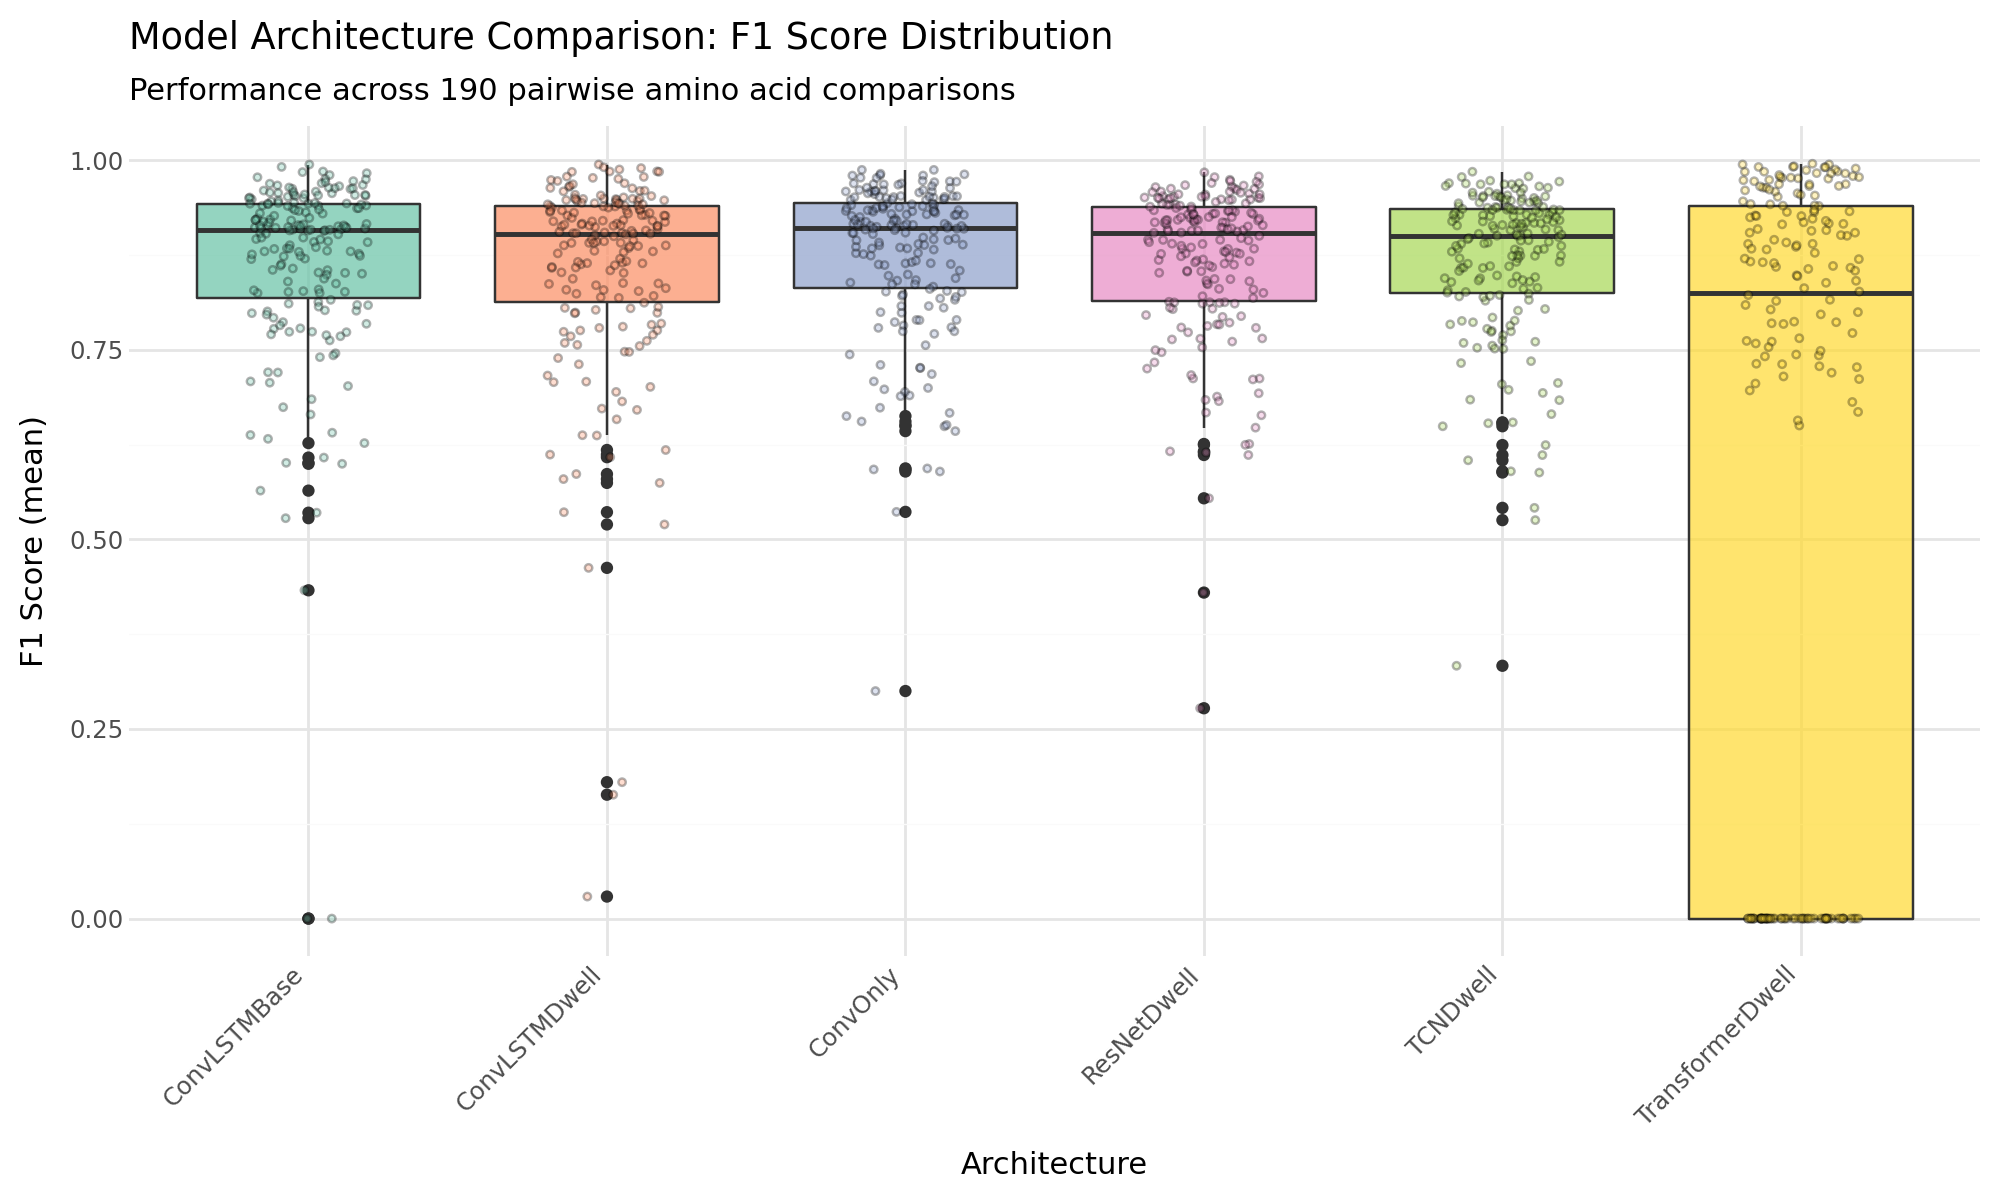

In [6]:
# Convert to pandas for plotnine
df_pd = df.to_pandas()

# Box plot of F1 scores by architecture
p1 = (
    p9.ggplot(df_pd, p9.aes(x="architecture", y="f1_mean", fill="architecture"))
    + p9.geom_boxplot(alpha=0.7)
    + p9.geom_jitter(width=0.2, alpha=0.3, size=1)
    + p9.labs(
        title="Model Architecture Comparison: F1 Score Distribution",
        subtitle=f"Performance across {df['pair'].n_unique()} pairwise amino acid comparisons",
        x="Architecture",
        y="F1 Score (mean)",
    )
    + p9.theme(
        axis_text_x=p9.element_text(rotation=45, hjust=1), legend_position="none", figure_size=(10, 6)
    )
    + p9.scale_fill_brewer(type="qual", palette="Set2")
)

p1.show()

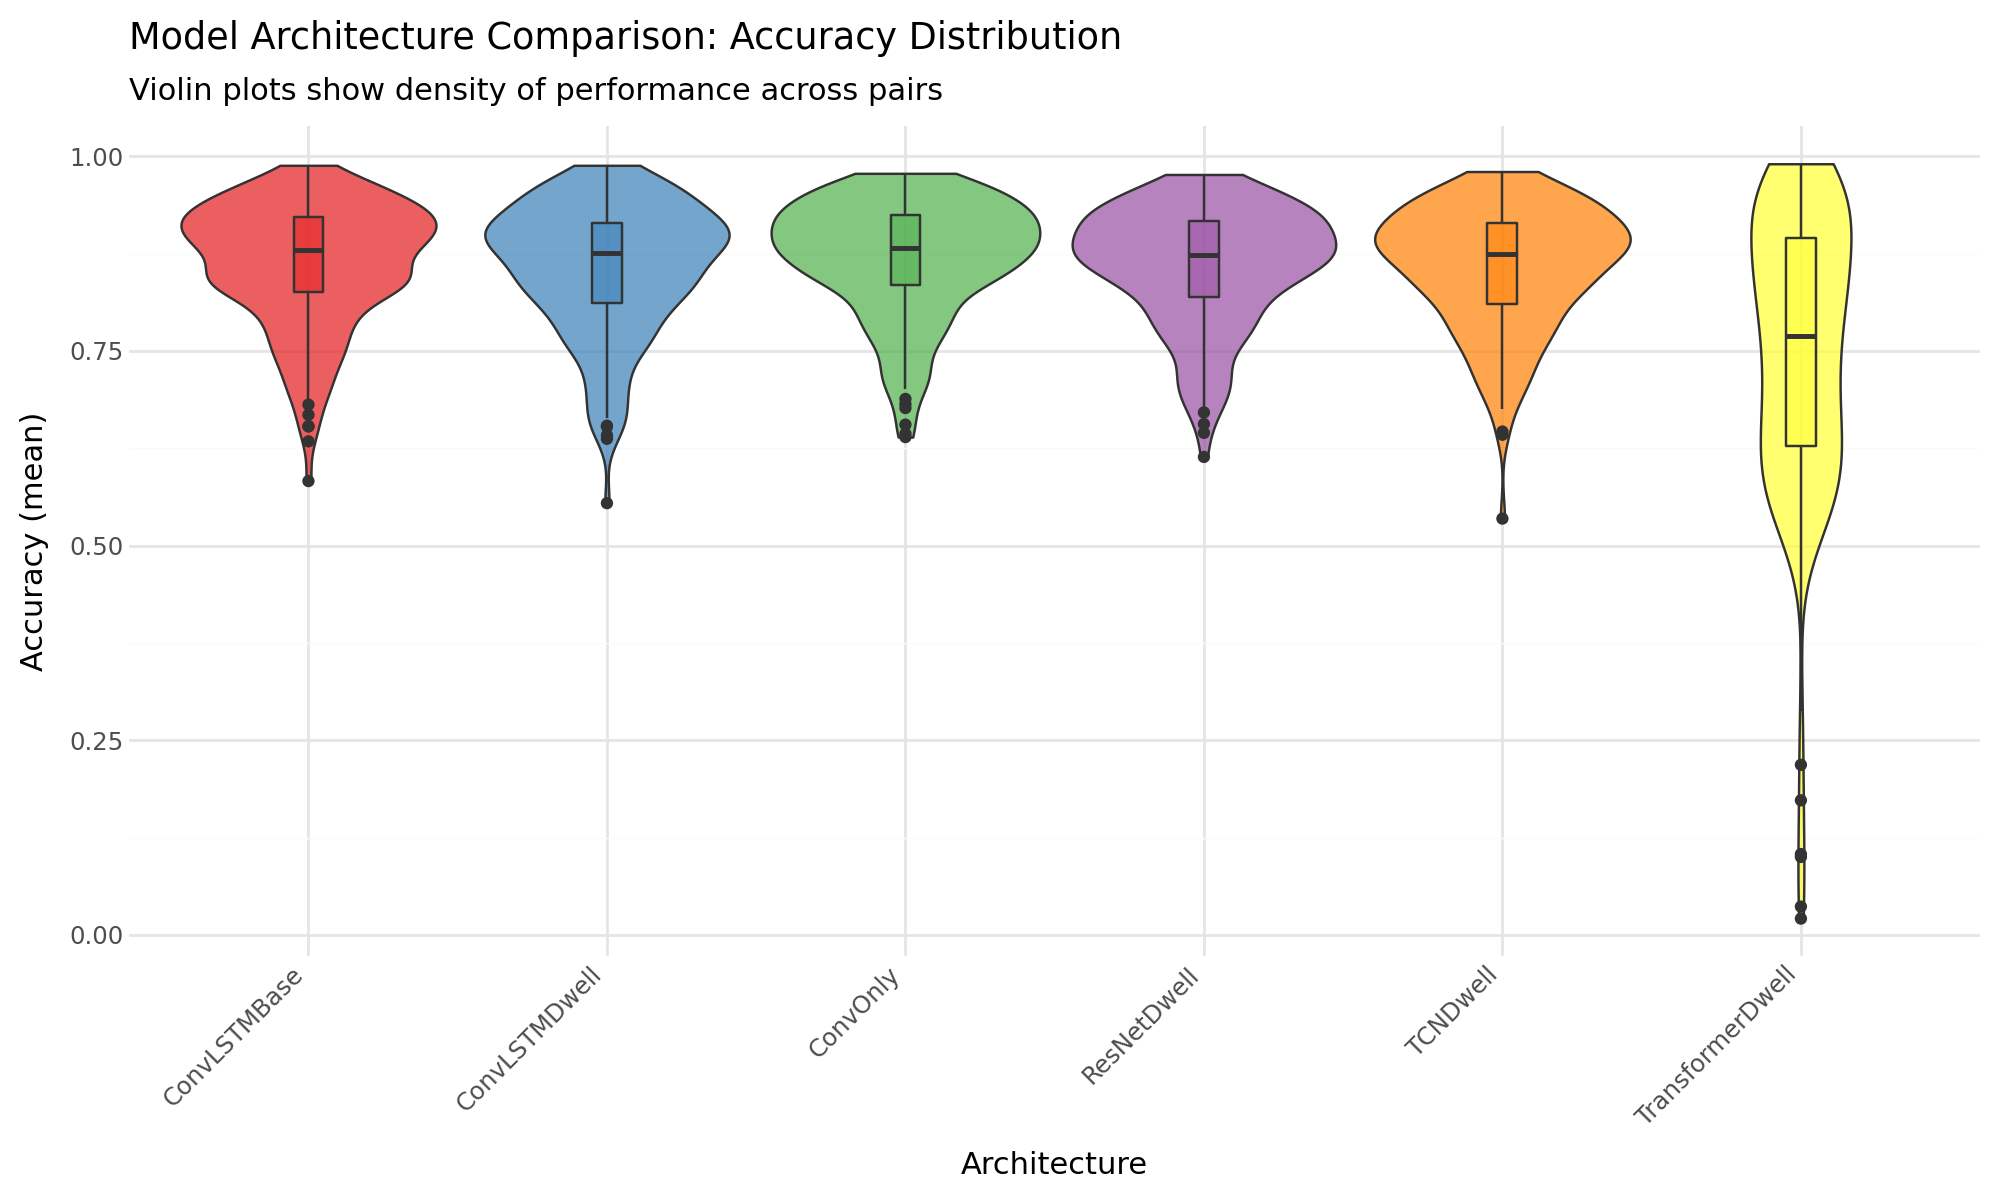

In [7]:
# Violin plot showing distribution density
p2 = (
    p9.ggplot(df_pd, p9.aes(x="architecture", y="accuracy_mean", fill="architecture"))
    + p9.geom_violin(alpha=0.7)
    + p9.geom_boxplot(width=0.1, alpha=0.5)
    + p9.labs(
        title="Model Architecture Comparison: Accuracy Distribution",
        subtitle="Violin plots show density of performance across pairs",
        x="Architecture",
        y="Accuracy (mean)",
    )
    + p9.theme(
        axis_text_x=p9.element_text(rotation=45, hjust=1), legend_position="none", figure_size=(10, 6)
    )
    + p9.scale_fill_brewer(type="qual", palette="Set1")
)

p2.show()

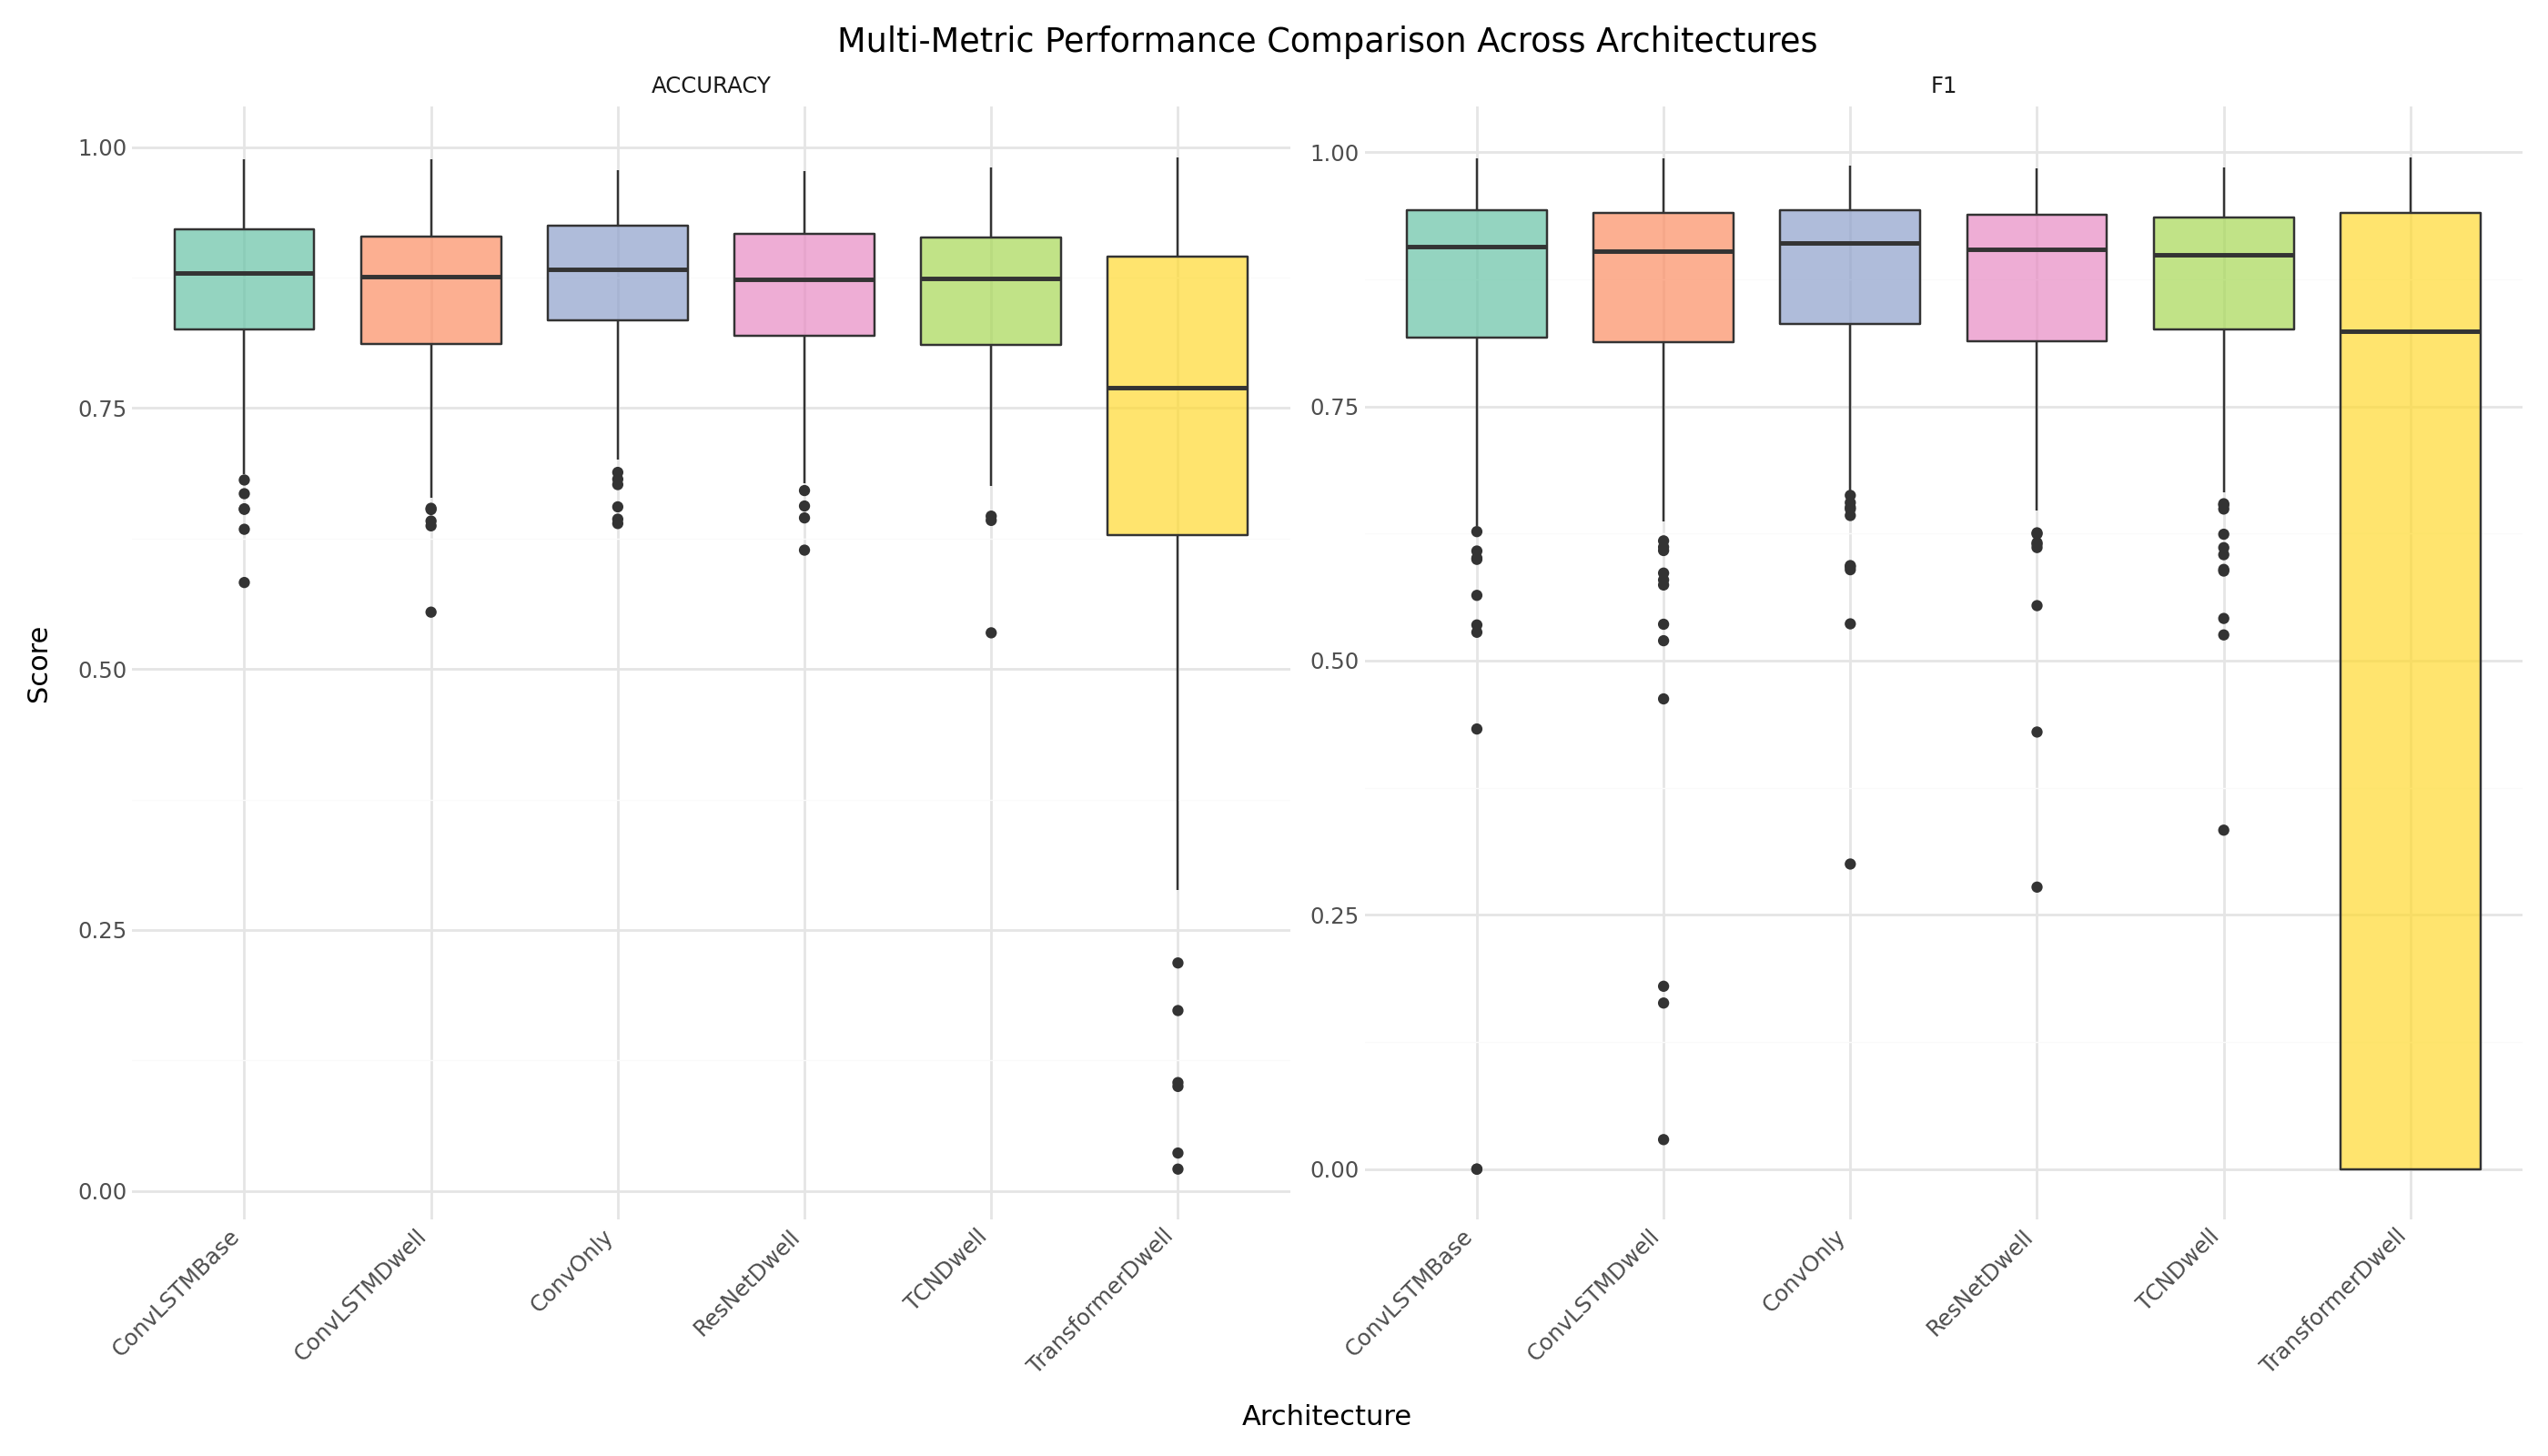

In [8]:
# Multi-metric comparison
# Build list of available metric columns
value_vars = []
if "accuracy_mean" in df_pd.columns:
    value_vars.append("accuracy_mean")
if "f1_mean" in df_pd.columns:
    value_vars.append("f1_mean")
if "auroc_mean" in df_pd.columns:
    value_vars.append("auroc_mean")
if "auprc_mean" in df_pd.columns:
    value_vars.append("auprc_mean")

if value_vars:
    metrics_long = df_pd.melt(
        id_vars=["pair", "architecture"],
        value_vars=value_vars,
        var_name="metric",
        value_name="score",
    )

    # Clean up metric names
    metrics_long["metric"] = metrics_long["metric"].str.replace("_mean", "").str.upper()

    p3 = (
        p9.ggplot(metrics_long, p9.aes(x="architecture", y="score", fill="architecture"))
        + p9.geom_boxplot(alpha=0.7)
        + p9.facet_wrap("~metric", scales="free_y")
        + p9.labs(
            title="Multi-Metric Performance Comparison Across Architectures",
            x="Architecture",
            y="Score",
        )
        + p9.theme(
            axis_text_x=p9.element_text(rotation=45, hjust=1), legend_position="none", figure_size=(14, 8)
        )
        + p9.scale_fill_brewer(type="qual", palette="Set2")
    )

    p3.show()
else:
    print("No metrics available for multi-metric comparison plot")

## Visualization 2: Dwell Time Feature Impact

Compare models with and without dwell time features to quantify their impact.
This assumes architectures like `ConvLSTMDwell` (with dwell) vs `ConvLSTMBase` (without dwell).

In [9]:
# Identify dwell vs non-dwell architectures
architectures = df_pd["architecture"].unique()
print(f"Available architectures: {architectures}")

# Try to identify dwell-enabled vs baseline models
dwell_models = [arch for arch in architectures if "dwell" in arch.lower()]
base_models = [arch for arch in architectures if "base" in arch.lower()]

print(f"\nDwell-enabled models: {dwell_models}")
print(f"Baseline models: {base_models}")

Available architectures: ['TCNDwell' 'ConvOnly' 'ResNetDwell' 'ConvLSTMBase' 'ConvLSTMDwell'
 'TransformerDwell']

Dwell-enabled models: ['TCNDwell', 'ResNetDwell', 'ConvLSTMDwell', 'TransformerDwell']
Baseline models: ['ConvLSTMBase']


In [10]:
# If we have both dwell and base models, create direct comparison
if dwell_models and base_models:
    # Create a subset for dwell comparison
    dwell_comparison = df_pd[df_pd["architecture"].isin(dwell_models + base_models)].copy()

    # Categorize as dwell or baseline
    dwell_comparison["feature_type"] = dwell_comparison["architecture"].apply(
        lambda x: "With Dwell Features" if "dwell" in x.lower() else "Baseline (No Dwell)"
    )

    # Calculate improvement for each pair
    if len(dwell_models) == 1 and len(base_models) == 1:
        dwell_arch = dwell_models[0]
        base_arch = base_models[0]

        dwell_df = df_pd[df_pd["architecture"] == dwell_arch][
            ["pair", "f1_mean", "accuracy_mean"]
        ].rename(columns={"f1_mean": "f1_dwell", "accuracy_mean": "acc_dwell"})
        base_df = df_pd[df_pd["architecture"] == base_arch][
            ["pair", "f1_mean", "accuracy_mean"]
        ].rename(columns={"f1_mean": "f1_base", "accuracy_mean": "acc_base"})

        improvement_df = dwell_df.merge(base_df, on="pair")
        improvement_df["f1_improvement"] = improvement_df["f1_dwell"] - improvement_df["f1_base"]
        improvement_df["acc_improvement"] = improvement_df["acc_dwell"] - improvement_df["acc_base"]

        print(f"\nDwell Time Feature Impact ({dwell_arch} vs {base_arch}):")
        print(
            f"Mean F1 improvement: {improvement_df['f1_improvement'].mean():.4f} ± {improvement_df['f1_improvement'].std():.4f}"
        )
        print(
            f"Mean Accuracy improvement: {improvement_df['acc_improvement'].mean():.4f} ± {improvement_df['acc_improvement'].std():.4f}"
        )
        print(
            f"Pairs where dwell helps (F1): {(improvement_df['f1_improvement'] > 0).sum()} / {len(improvement_df)}"
        )
        print(
            f"Pairs where dwell helps (Acc): {(improvement_df['acc_improvement'] > 0).sum()} / {len(improvement_df)}"
        )
else:
    print("Note: Could not identify both dwell and baseline models for direct comparison.")
    dwell_comparison = df_pd.copy()
    dwell_comparison["feature_type"] = dwell_comparison["architecture"]

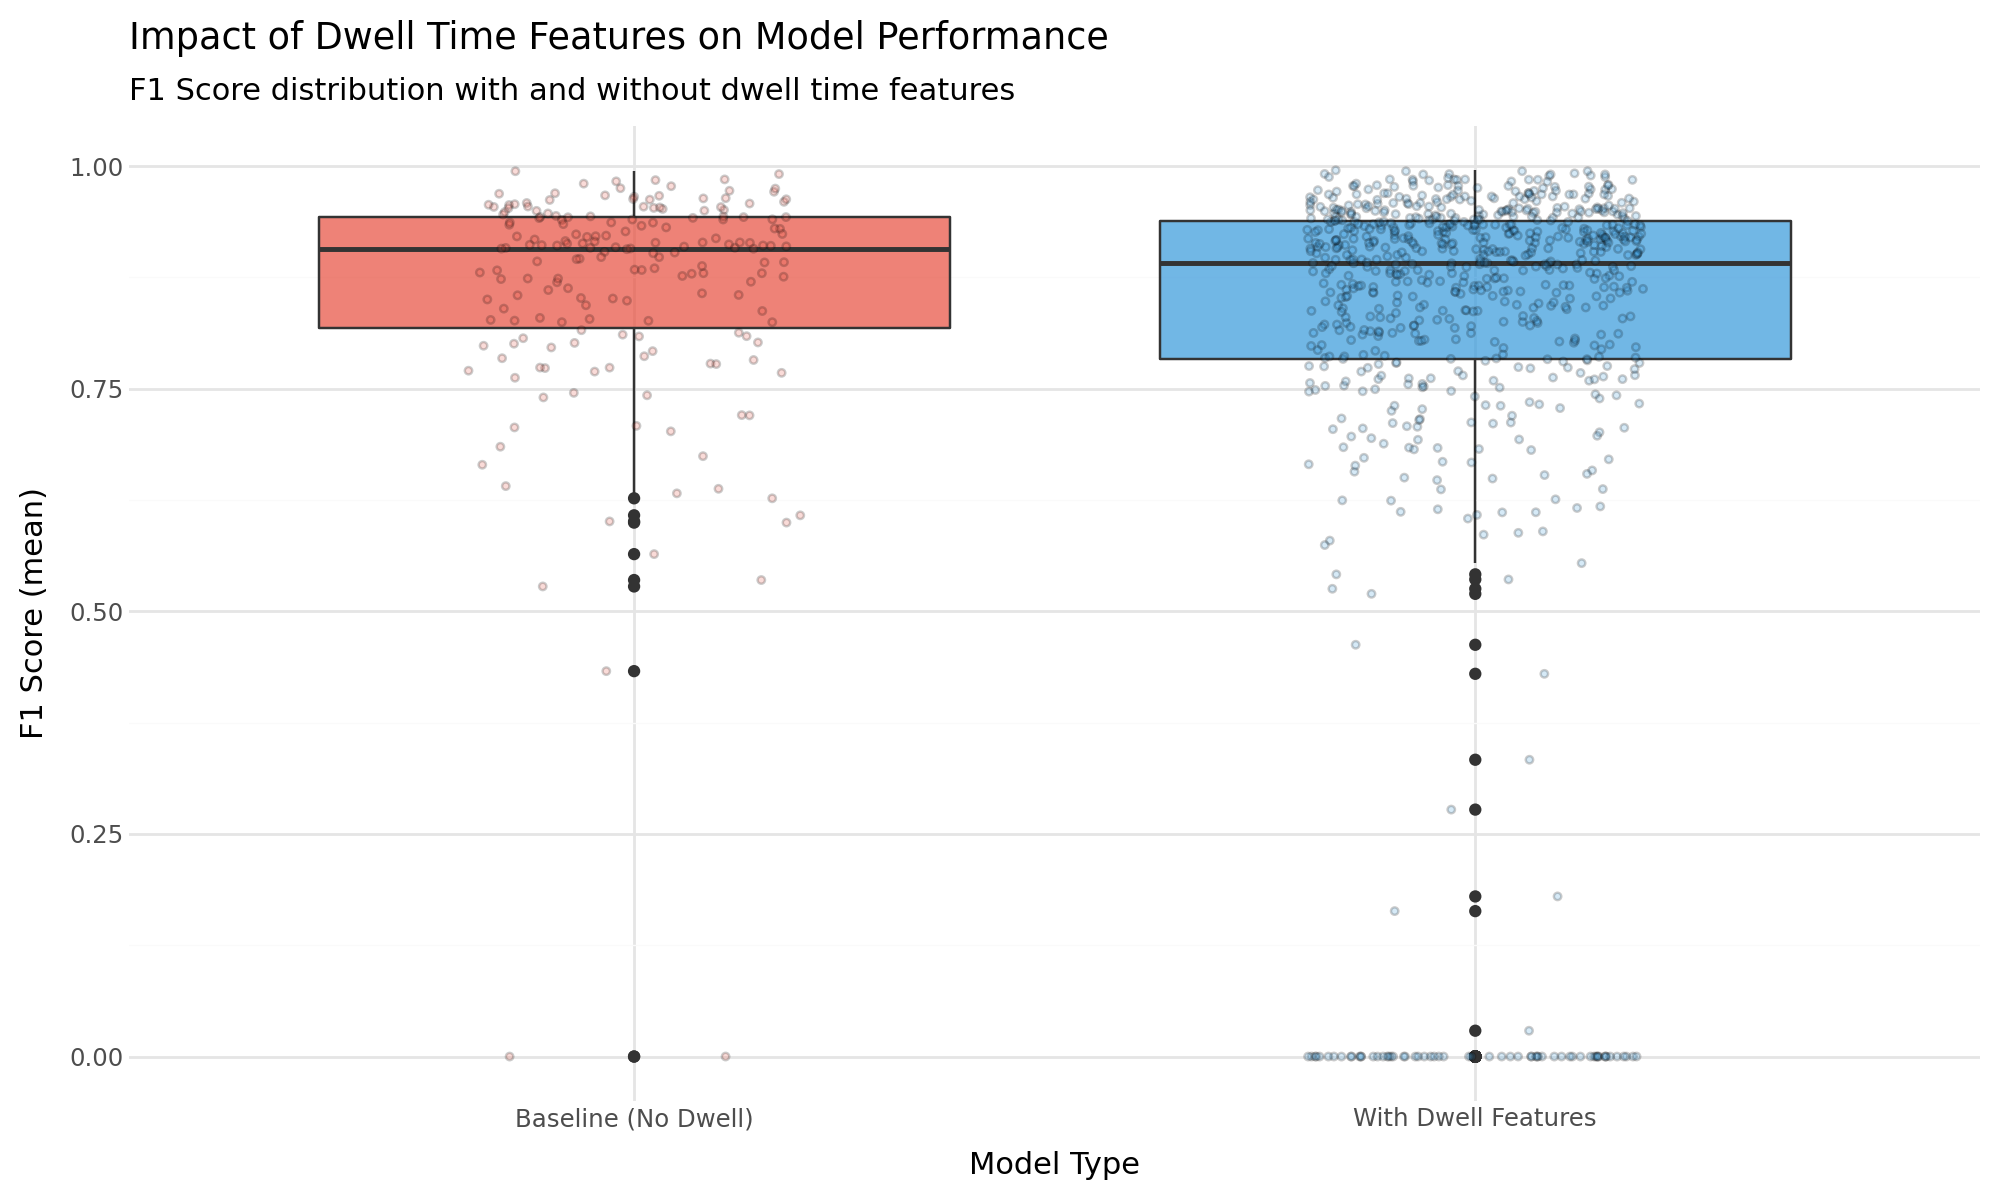

In [11]:
# Side-by-side comparison of dwell vs baseline
if dwell_models and base_models:
    p4 = (
        p9.ggplot(dwell_comparison, p9.aes(x="feature_type", y="f1_mean", fill="feature_type"))
        + p9.geom_boxplot(alpha=0.7)
        + p9.geom_jitter(width=0.2, alpha=0.2, size=1)
        + p9.labs(
            title="Impact of Dwell Time Features on Model Performance",
            subtitle="F1 Score distribution with and without dwell time features",
            x="Model Type",
            y="F1 Score (mean)",
        )
        + p9.theme(legend_position="none", figure_size=(10, 6))
        + p9.scale_fill_manual(values=["#E74C3C", "#3498DB"])
    )

    p4.show()

In [12]:
# Histogram of improvement from dwell features
if dwell_models and base_models and len(dwell_models) == 1 and len(base_models) == 1:
    p5 = (
        p9.ggplot(improvement_df, p9.aes(x="f1_improvement"))
        + p9.geom_histogram(bins=30, fill="#2ECC71", alpha=0.7, color="black")
        + p9.geom_vline(xintercept=0, linetype="dashed", color="red", size=1)
        + p9.labs(
            title="Distribution of F1 Score Improvement from Dwell Time Features",
            subtitle=f"Comparing {dwell_arch} vs {base_arch} across {len(improvement_df)} pairs",
            x="F1 Score Improvement (Dwell - Baseline)",
            y="Count",
        )
        + p9.theme(figure_size=(10, 6))
    )

    print(p5)

    # Show pairs with largest improvements and degradations
    print("\nTop 10 pairs with LARGEST improvement from dwell features:")
    (
        GT(improvement_df.nlargest(10, "f1_improvement")[
            ["pair", "f1_base", "f1_dwell", "f1_improvement"]
        ])
        .tab_header(title="Top 10 Pairs: Largest Improvement from Dwell Features")
        .fmt_number(columns=["f1_base", "f1_dwell", "f1_improvement"], decimals=4)
        .data_color(
            columns=["f1_improvement"],
            palette=["#fee5d9", "#31a354"],
            domain=[0.0, 0.2]
        )
    )

    print("\nTop 10 pairs with LARGEST degradation from dwell features:")
    (
        GT(improvement_df.nsmallest(10, "f1_improvement")[
            ["pair", "f1_base", "f1_dwell", "f1_improvement"]
        ])
        .tab_header(title="Top 10 Pairs: Largest Degradation from Dwell Features")
        .fmt_number(columns=["f1_base", "f1_dwell", "f1_improvement"], decimals=4)
        .data_color(
            columns=["f1_improvement"],
            palette=["#e5f5e0", "#a50f15"],
            domain=[-0.2, 0.0]
        )
    )

In [13]:
# Scatter plot: baseline vs dwell performance
if dwell_models and base_models and len(dwell_models) == 1 and len(base_models) == 1:
    p6 = (
        p9.ggplot(improvement_df, p9.aes(x="f1_base", y="f1_dwell"))
        + p9.geom_point(alpha=0.6, size=2, color="#9B59B6")
        + p9.geom_abline(intercept=0, slope=1, linetype="dashed", color="red", size=0.8)
        + p9.labs(
            title="Baseline vs Dwell-Enhanced Model Performance",
            subtitle="Points above red line indicate dwell features improve performance",
            x=f"F1 Score - {base_arch}",
            y=f"F1 Score - {dwell_arch}",
        )
        + p9.theme(figure_size=(10, 10))
        + p9.coord_fixed()
    )

    p6.show()

## Top and Bottom Performing Amino Acid Pairs

Identify which amino acid pairs are easiest and hardest to classify.

In [14]:
# Average performance per pair across all architectures
# Build list of available metrics for aggregation
agg_metrics = [
    pl.col("f1_mean").mean().alias("avg_f1"),
    pl.col("accuracy_mean").mean().alias("avg_accuracy"),
]

# Add AUROC if available
if "auroc_mean" in df.columns:
    agg_metrics.append(pl.col("auroc_mean").mean().alias("avg_auroc"))

# Add AUPRC if available
if "auprc_mean" in df.columns:
    agg_metrics.append(pl.col("auprc_mean").mean().alias("avg_auprc"))

pair_performance = (
    df.group_by("pair")
    .agg(agg_metrics)
    .sort("avg_f1", descending=True)
)

# Get top and bottom 15
top_pairs = pair_performance.head(15)
bottom_pairs = pair_performance.tail(15)

print("Top 15 Easiest Pairs to Classify:")
(
    GT(top_pairs)
    .tab_header(title="Top 15 Easiest Pairs to Classify")
    .fmt_number(columns=["avg_f1", "avg_accuracy"], decimals=4)
    .data_color(
        columns=["avg_f1"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.8, 1.0]
    )
)

print("\nTop 15 Hardest Pairs to Classify:")
(
    GT(bottom_pairs)
    .tab_header(title="Top 15 Hardest Pairs to Classify")
    .fmt_number(columns=["avg_f1", "avg_accuracy"], decimals=4)
    .data_color(
        columns=["avg_f1"],
        palette=["#a50f15", "#fee5d9"],
        domain=[0.0, 0.8]
    )
)

Top 15 Easiest Pairs to Classify:

Top 15 Hardest Pairs to Classify:


GT(_tbl_data=shape: (15, 3)
┌─────────┬──────────┬──────────────┐
│ pair    ┆ avg_f1   ┆ avg_accuracy │
│ ---     ┆ ---      ┆ ---          │
│ str     ┆ f64      ┆ f64          │
╞═════════╪══════════╪══════════════╡
│ Met_Thr ┆ 0.571433 ┆ 0.683667     │
│ Ser_Thr ┆ 0.566667 ┆ 0.8586       │
│ His_Trp ┆ 0.562917 ┆ 0.7458       │
│ His_Ile ┆ 0.54485  ┆ 0.792633     │
│ Pro_Trp ┆ 0.53935  ┆ 0.8599       │
│ …       ┆ …        ┆ …            │
│ Leu_Trp ┆ 0.48305  ┆ 0.762333     │
│ Leu_Phe ┆ 0.438217 ┆ 0.6399       │
│ Arg_Cys ┆ 0.39205  ┆ 0.7595       │
│ Asn_Cys ┆ 0.370933 ┆ 0.681133     │
│ Asp_Cys ┆ 0.1566   ┆ 0.917867     │
└─────────┴──────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x147664f9bfb0>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='avg_f1', type=<ColInfoTypeEnum.default: 1>, column_label='avg_f1', column_align='right', column_width=None), ColInfo(var='avg_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='avg_accuracy', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x147664fcd5e0>, _spanners=Spanners([]), _heading=Heading(title='Top 15 Hardest Pairs to Classify', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x147664fb3470>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1476ed6c4dd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='avg_f1', rows=[0], mask=None), grpname=None, colname='avg_f1', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e5a8a1')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[1], mask=None), grpname=None, colname='avg_f1', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e4a7a0')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[2], mask=None), grpname=None, colname='avg_f1', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e4a69f')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[3], mask=None), grpname=None, colname='avg_f1', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e2a19a')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[4], mask=None), grpname=None, colname='avg_f1', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e19f99')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[5], mask=None), grpname=None, colname='avg_f1', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e09e98')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[6], mask=None), grpname=None, colname='avg_f1', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e09c96')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[7], mask=None), grpname=None, colname='avg_f1', rownum=7, colnum=None, styles=[CellStyleText(color='#000000', font=None

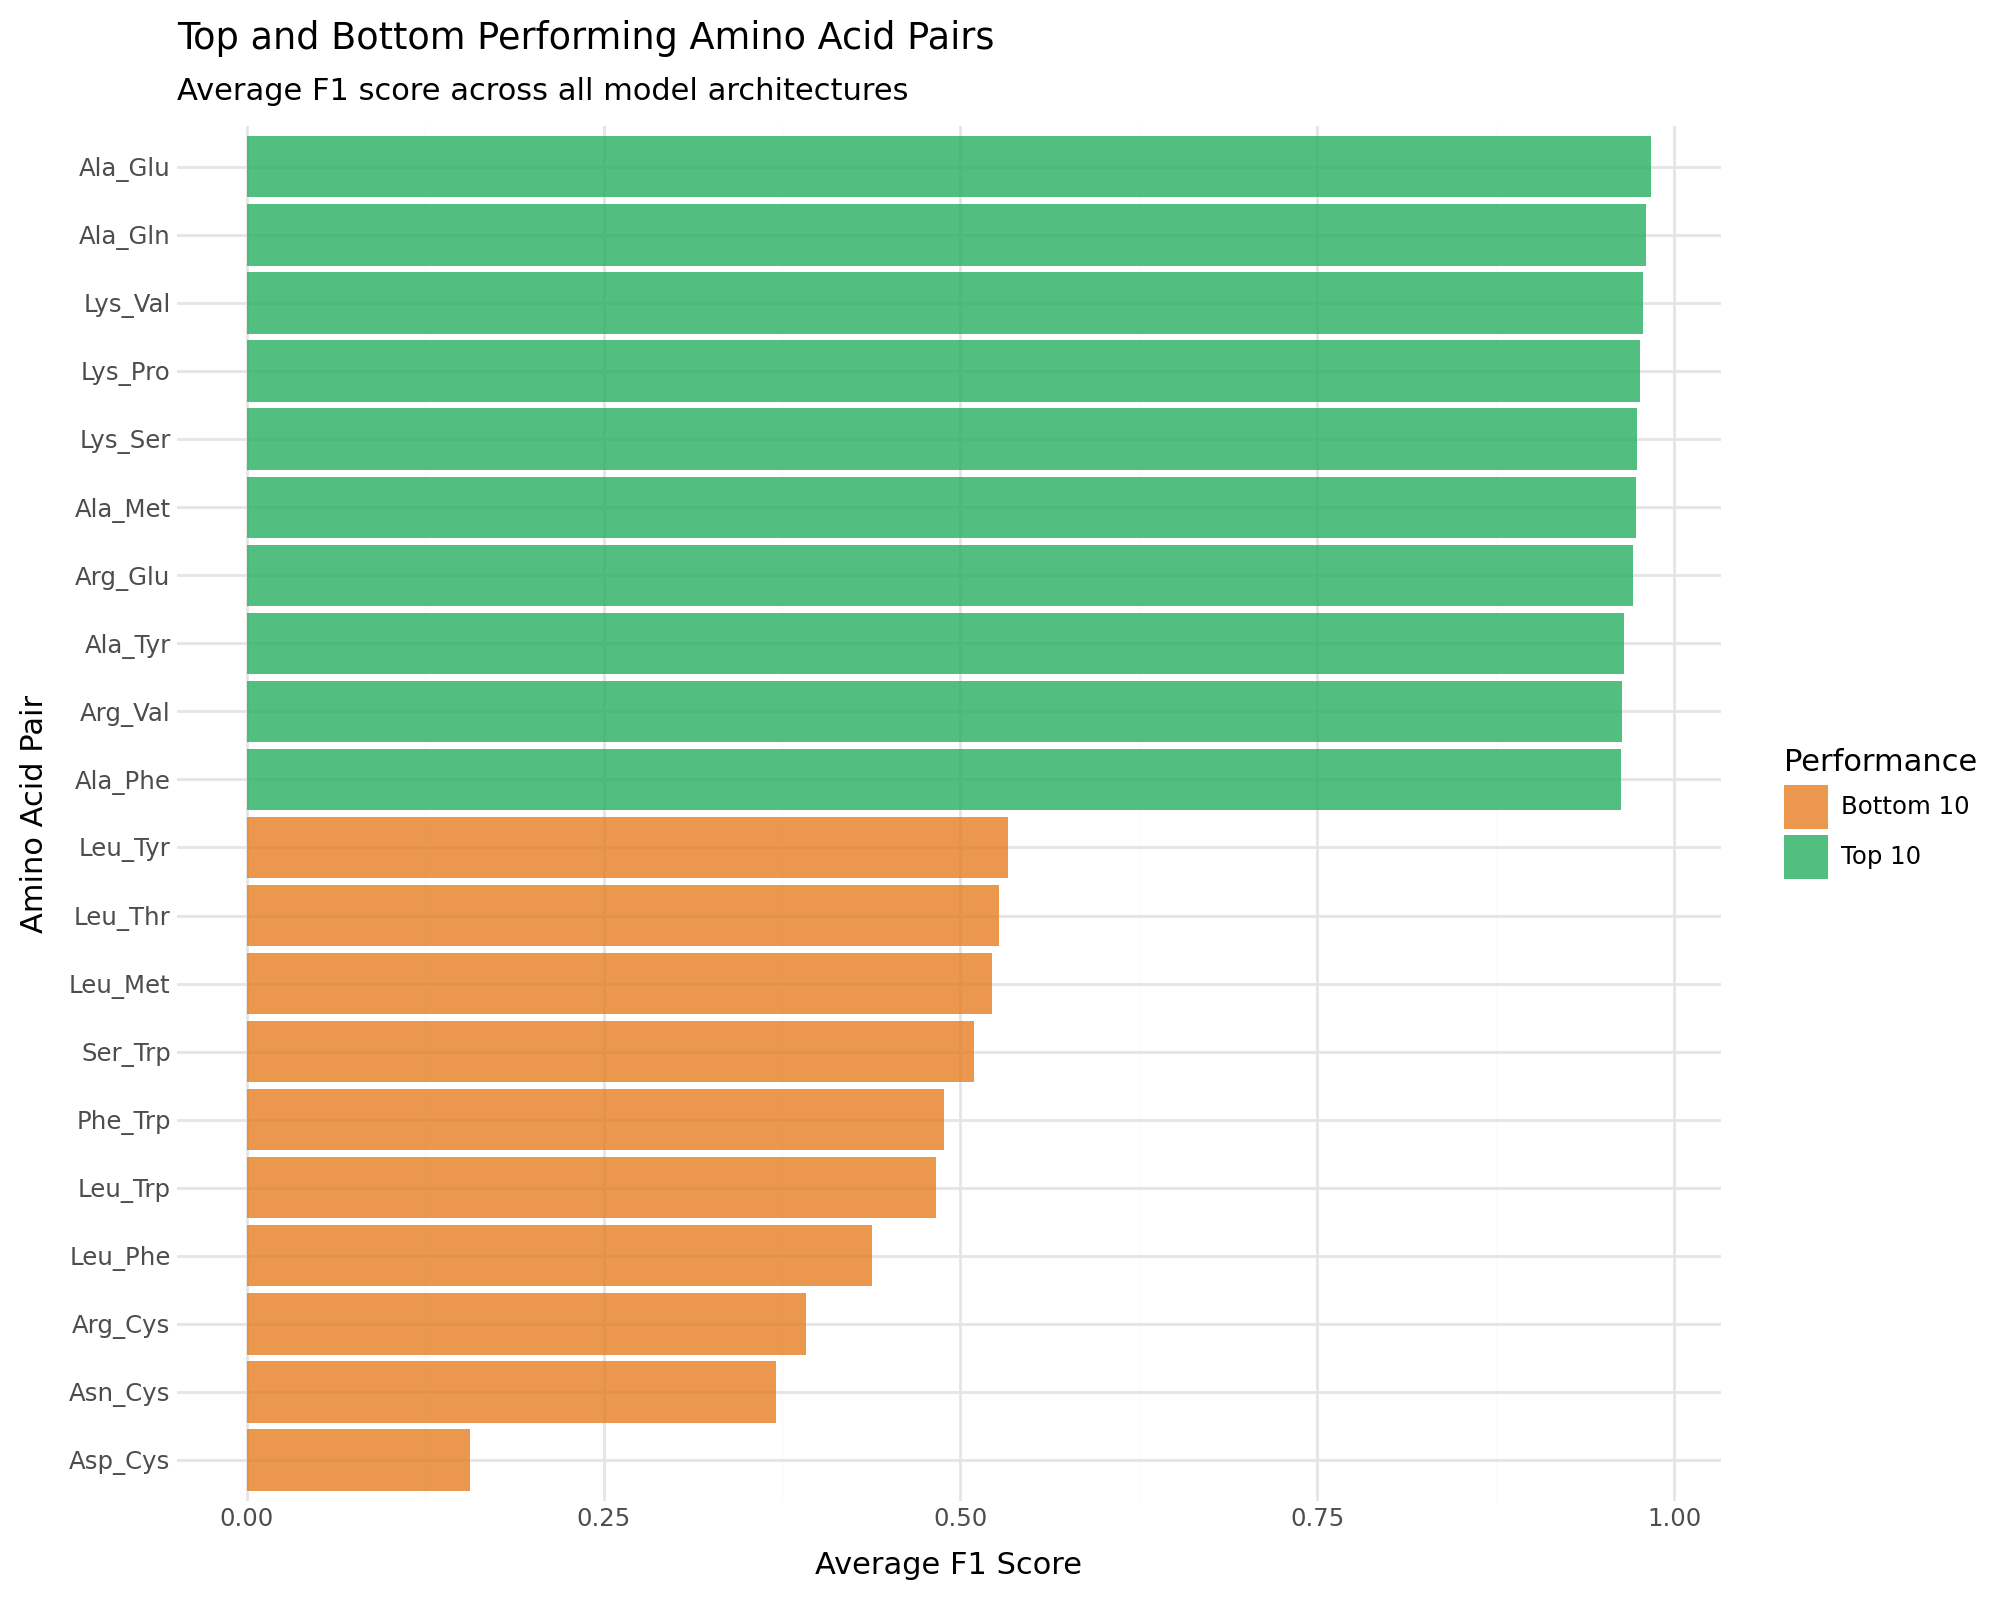

In [15]:
# Bar plot of top and bottom pairs
extreme_pairs = pl.concat([top_pairs.head(10), bottom_pairs.tail(10)])
extreme_pairs_pd = extreme_pairs.to_pandas()
extreme_pairs_pd["category"] = ["Top 10"] * 10 + ["Bottom 10"] * 10

p7 = (
    p9.ggplot(extreme_pairs_pd, p9.aes(x="reorder(pair, avg_f1)", y="avg_f1", fill="category"))
    + p9.geom_col(alpha=0.8)
    + p9.coord_flip()
    + p9.labs(
        title="Top and Bottom Performing Amino Acid Pairs",
        subtitle="Average F1 score across all model architectures",
        x="Amino Acid Pair",
        y="Average F1 Score",
        fill="Performance",
    )
    + p9.theme(figure_size=(10, 8))
    + p9.scale_fill_manual(values=["#E67E22", "#27AE60"])
)

p7.show()

## Performance Variability Analysis

Examine which pairs have consistent vs variable performance across architectures.

In [16]:
# Calculate coefficient of variation (std/mean) for each pair across architectures
pair_variability = (
    df.group_by("pair")
    .agg(
        [
            pl.col("f1_mean").mean().alias("avg_f1"),
            pl.col("f1_mean").std().alias("std_f1"),
        ]
    )
    .with_columns((pl.col("std_f1") / pl.col("avg_f1")).alias("cv_f1"))
    .sort("cv_f1", descending=True)
)

print("Top 15 pairs with HIGHEST variability across architectures:")
(
    GT(pair_variability.head(15))
    .tab_header(
        title="Top 15 Pairs with Highest Variability",
        subtitle="Architectures disagree most on these pairs"
    )
    .fmt_number(columns=["avg_f1", "std_f1", "cv_f1"], decimals=4)
    .data_color(
        columns=["cv_f1"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.0, 1.0]
    )
)

print("\nTop 15 pairs with LOWEST variability (most consistent):")
(
    GT(pair_variability.tail(15))
    .tab_header(
        title="Top 15 Pairs with Lowest Variability",
        subtitle="Architectures agree most on these pairs"
    )
    .fmt_number(columns=["avg_f1", "std_f1", "cv_f1"], decimals=4)
    .data_color(
        columns=["cv_f1"],
        palette=["#31a354", "#fee5d9"],
        domain=[0.0, 0.1]
    )
)

Top 15 pairs with HIGHEST variability across architectures:

Top 15 pairs with LOWEST variability (most consistent):


GT(_tbl_data=shape: (15, 4)
┌─────────┬──────────┬──────────┬──────────┐
│ pair    ┆ avg_f1   ┆ std_f1   ┆ cv_f1    │
│ ---     ┆ ---      ┆ ---      ┆ ---      │
│ str     ┆ f64      ┆ f64      ┆ f64      │
╞═════════╪══════════╪══════════╪══════════╡
│ His_Pro ┆ 0.8608   ┆ 0.007866 ┆ 0.009138 │
│ Arg_Leu ┆ 0.952633 ┆ 0.008325 ┆ 0.008738 │
│ Met_Phe ┆ 0.698583 ┆ 0.005872 ┆ 0.008405 │
│ Lys_Val ┆ 0.9785   ┆ 0.007748 ┆ 0.007918 │
│ Phe_Val ┆ 0.84165  ┆ 0.006413 ┆ 0.00762  │
│ …       ┆ …        ┆ …        ┆ …        │
│ Arg_Tyr ┆ 0.93485  ┆ 0.005242 ┆ 0.005608 │
│ Lys_Ser ┆ 0.97385  ┆ 0.005209 ┆ 0.005349 │
│ His_Leu ┆ 0.7829   ┆ 0.004082 ┆ 0.005214 │
│ Arg_His ┆ 0.937983 ┆ 0.003987 ┆ 0.00425  │
│ Lys_Pro ┆ 0.976067 ┆ 0.003916 ┆ 0.004012 │
└─────────┴──────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x147663225bb0>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='avg_f1', type=<ColInfoTypeEnum.default: 1>, column_label='avg_f1', column_align='right', column_width=None), ColInfo(var='std_f1', type=<ColInfoTypeEnum.default: 1>, column_label='std_f1', column_align='right', column_width=None), ColInfo(var='cv_f1', type=<ColInfoTypeEnum.default: 1>, column_label='cv_f1', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1476608f8320>, _spanners=Spanners([]), _heading=Heading(title='Top 15 Pairs with Lowest Variability', subtitle='Architectures agree most on these pairs', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x147663226810>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x147663225a60>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='cv_f1', rows=[0], mask=None), grpname=None, colname='cv_f1', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#44a960')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[1], mask=None), grpname=None, colname='cv_f1', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#43a960')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[2], mask=None), grpname=None, colname='cv_f1', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#42a95f')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[3], mask=None), grpname=None, colname='cv_f1', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#41a85f')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[4], mask=None), grpname=None, colname='cv_f1', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#41a85e')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[5], mask=None), grpname=None, colname='cv_f1', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#41a85e')]), StyleInfo(locname=LocBody(columns='cv_f1', rows=[6], mask=None), grpname=None, colname='cv_f1', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None

In [17]:
# Scatter plot: mean performance vs variability
pair_var_pd = pair_variability.to_pandas()

p8 = (
    p9.ggplot(pair_var_pd, p9.aes(x="avg_f1", y="std_f1"))
    + p9.geom_point(alpha=0.6, size=2, color="#E74C3C")
    + p9.labs(
        title="Performance vs Variability Across Amino Acid Pairs",
        subtitle="Each point represents one amino acid pair",
        x="Average F1 Score",
        y="Standard Deviation (across architectures)",
    )
    + p9.theme(figure_size=(10, 6))
)

print(p8)

<ggplot: (1000 x 600)>


## Export Summary Statistics

In [18]:
# Create a comprehensive summary
print("=" * 80)
print("COMPREHENSIVE SUMMARY")
print("=" * 80)
print(f"\nTotal amino acid pairs analyzed: {df['pair'].n_unique()}")
print(f"Total architectures compared: {df['architecture'].n_unique()}")
print(f"Architectures: {', '.join(df['architecture'].unique().to_list())}")

print("\n" + "=" * 80)
print("OVERALL ARCHITECTURE RANKINGS")
print("=" * 80)

(
    GT(summary)
    .tab_header(
        title="Overall Architecture Rankings",
        subtitle="Performance metrics averaged across all pairs"
    )
    .fmt_number(
        columns=["avg_accuracy", "std_accuracy", "avg_f1", "std_f1"],
        decimals=4
    )
    .data_color(
        columns=["avg_f1"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.5, 1.0]
    )
)

# Statistical significance of differences (if applicable)
if len(architectures) >= 2:
    print("\n" + "=" * 80)
    print("PERFORMANCE DIFFERENCES")
    print("=" * 80)

    diff_data = []
    for i, arch1 in enumerate(architectures):
        for arch2 in architectures[i + 1 :]:
            data1 = df_pd[df_pd["architecture"] == arch1]["f1_mean"]
            data2 = df_pd[df_pd["architecture"] == arch2]["f1_mean"]
            diff = data1.mean() - data2.mean()
            diff_data.append({
                "Comparison": f"{arch1} vs {arch2}",
                "ΔF1": diff
            })

    import pandas as pd
    diff_df = pd.DataFrame(diff_data)

    # Display without diverging color scale (not supported in current great_tables version)
    (
        GT(diff_df)
        .tab_header(
            title="Pairwise Architecture Performance Differences",
            subtitle="Difference in mean F1 score (positive = first arch better)"
        )
        .fmt_number(columns=["ΔF1"], decimals=4, force_sign=True)
    )

COMPREHENSIVE SUMMARY

Total amino acid pairs analyzed: 190
Total architectures compared: 6
Architectures: ResNetDwell, ConvLSTMBase, ConvLSTMDwell, ConvOnly, TCNDwell, TransformerDwell

OVERALL ARCHITECTURE RANKINGS

PERFORMANCE DIFFERENCES


## Tier 1 Advanced Analyses

The following sections provide in-depth statistical analyses to address:
1. **Hierarchical structure** in architecture and pair performance patterns
2. **Consistency metrics** quantifying robustness and difficulty
3. **Variance decomposition** using two-way ANOVA to identify interaction effects

These analyses help answer:
- Which architectures are most robust across different pair types?
- Which AA pairs show consensus vs variable performance across architectures?
- How much variance is due to architecture choice vs pair difficulty vs interactions?

Reference: Issue #72

In [19]:
# Additional imports for Tier 1 analyses
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Set seaborn style
sns.set_palette("husl")

### Class Balance Analysis

Extract class balance information from individual test_metrics.json files to investigate whether class imbalance impacts training performance.

In [20]:
import json
from pathlib import Path

# Base directory for metrics
metrics_base = Path("/scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/metrics/comparison/pairwise")

# Get all unique pairs from the dataframe
all_pairs = df["pair"].unique().to_list()

# Extract class balance from JSON files
# Strategy: Average class counts across all 6 architectures for each pair
class_balance_data = []

print(f"Extracting class balance from {len(all_pairs)} pairs × 6 architectures...")

for pair in all_pairs:
    pair_class0_counts = []
    pair_class1_counts = []

    # Loop through all architectures for this pair
    for arch in df["architecture"].unique():
        json_path = metrics_base / pair / arch / "test_metrics.json"

        if json_path.exists():
            try:
                with open(json_path) as f:
                    metrics = json.load(f)

                # Extract confusion matrix: [[TN, FP], [FN, TP]]
                cm = metrics.get("confusion_matrix", [[0, 0], [0, 0]])

                # Calculate class counts
                class0_count = cm[0][0] + cm[0][1]  # TN + FP
                class1_count = cm[1][0] + cm[1][1]  # FN + TP

                pair_class0_counts.append(class0_count)
                pair_class1_counts.append(class1_count)
            except Exception as e:
                print(f"Warning: Could not read {json_path}: {e}")
        else:
            print(f"Warning: Missing file {json_path}")

    # Calculate average class counts across all architectures
    if pair_class0_counts and pair_class1_counts:
        avg_class0 = np.mean(pair_class0_counts)
        avg_class1 = np.mean(pair_class1_counts)
        total_samples = avg_class0 + avg_class1

        # Calculate balance score: 1 - |class0 - class1| / total
        # Ranges from 0.5 (highly imbalanced) to 1.0 (perfectly balanced)
        balance_score = 1 - abs(avg_class0 - avg_class1) / total_samples

        # Also calculate imbalance ratio for reference
        imbalance_ratio = max(avg_class0, avg_class1) / min(avg_class0, avg_class1)

        class_balance_data.append({
            "pair": pair,
            "class0_count": avg_class0,
            "class1_count": avg_class1,
            "total_samples": total_samples,
            "balance_score": balance_score,
            "imbalance_ratio": imbalance_ratio
        })

# Create DataFrame with class balance information
class_balance_df = pl.DataFrame(class_balance_data)

print(f"\nSuccessfully extracted class balance for {len(class_balance_df)} pairs")
print("\nClass balance statistics:")
print(f"  Mean balance score: {class_balance_df['balance_score'].mean():.4f}")
print(f"  Min balance score:  {class_balance_df['balance_score'].min():.4f} (most imbalanced)")
print(f"  Max balance score:  {class_balance_df['balance_score'].max():.4f} (most balanced)")

# Show top 10 most imbalanced pairs
print("\nTop 10 MOST IMBALANCED pairs:")
(
    GT(class_balance_df.sort("balance_score").head(10).to_pandas())
    .tab_header(
        title="Top 10 Most Imbalanced Pairs",
        subtitle="Lowest balance score = highest class imbalance"
    )
    .fmt_number(columns=["class0_count", "class1_count", "total_samples"], decimals=1)
    .fmt_number(columns=["balance_score", "imbalance_ratio"], decimals=4)
    .data_color(
        columns=["balance_score"],
        palette=["#a50f15", "#fee5d9"],
        domain=[0.5, 1.0]
    )
)

Extracting class balance from 190 pairs × 6 architectures...

Successfully extracted class balance for 190 pairs

Class balance statistics:
  Mean balance score: 0.4514
  Min balance score:  0.0189 (most imbalanced)
  Max balance score:  0.9781 (most balanced)

Top 10 MOST IMBALANCED pairs:


GT(_tbl_data=      pair  class0_count  class1_count  total_samples  balance_score  \
0  Ala_Ser          43.0        4497.0         4540.0       0.018943   
1  Ala_Val          36.0        3163.0         3199.0       0.022507   
2  Ala_Pro          39.0        3355.0         3394.0       0.022982   
3  Cys_Ser          74.0        4493.0         4567.0       0.032406   
4  Ala_Leu          34.0        1924.0         1958.0       0.034729   
5  Ala_Glu          43.0        2375.0         2418.0       0.035567   
6  Cys_Val          60.0        3167.0         3227.0       0.037186   
7  Cys_Pro          64.0        3357.0         3421.0       0.037416   
8  Ala_Asp          27.0        1263.0         1290.0       0.041860   
9  Ala_Gln          27.0        1207.0         1234.0       0.043760   

   imbalance_ratio  
0       104.581395  
1        87.861111  
2        86.025641  
3        60.716216  
4        56.588235  
5        55.232558  
6        52.783333  
7        52.453125  
8        46.777778  
9        44.703704  , _body=<great_tables._gt_data.Body object at 0x1476632db140>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='class0_count', type=<ColInfoTypeEnum.default: 1>, column_label='class0_count', column_align='right', column_width=None), ColInfo(var='class1_count', type=<ColInfoTypeEnum.default: 1>, column_label='class1_count', column_align='right', column_width=None), ColInfo(var='total_samples', type=<ColInfoTypeEnum.default: 1>, column_label='total_samples', column_align='right', column_width=None), ColInfo(var='balance_score', type=<ColInfoTypeEnum.default: 1>, column_label='balance_score', column_align='right', column_width=None), ColInfo(var='imbalance_ratio', type=<ColInfoTypeEnum.default: 1>, column_label='imbalance_ratio', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1476609e1fd0>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Most Imbalanced Pairs', subtitle='Lowest balance score = highest class imbalance', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x147631fba750>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x147631fba840>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='balance_score', rows=[0], mask=None), grpname=None, colname='balance_score', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[1], mask=None), grpname=None, colname='balance_score', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[2], mask=None), grpname=None, colname='balance_score', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[3], mask=None), grpname=None, colname='balance_score', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[4], mask=None), grpname=None, colname='balance_score', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, 

In [21]:
# Create row annotation DataFrame for clustermap
# This will be used to add a color bar showing class balance scores next to the heatmap rows

import pandas as pd

# Convert class balance data to pandas (for seaborn compatibility)
class_balance_pd = class_balance_df.to_pandas()

# Create a Series indexed by pair name with balance scores
# This will be used as the row_colors parameter in sns.clustermap()
row_colors_data = class_balance_pd.set_index("pair")["balance_score"]

# Note: row_colors_data will be automatically reordered by seaborn.clustermap()
# to match the clustered row order

print(f"\nCreated row annotation data for {len(row_colors_data)} pairs")
print(f"Balance score range: [{row_colors_data.min():.4f}, {row_colors_data.max():.4f}]")


Created row annotation data for 190 pairs
Balance score range: [0.0189, 0.9781]


### 1. Clustered Heatmap with Hierarchical Clustering

This heatmap shows F1 scores for all AA pairs (rows) vs architectures (columns), with hierarchical clustering applied to both dimensions. Clustering reveals:
- Which AA pairs have similar performance patterns across architectures
- Which architectures perform similarly across different pairs
- Natural groupings and outliers in the performance landscape

<Figure size 1200x2000 with 0 Axes>

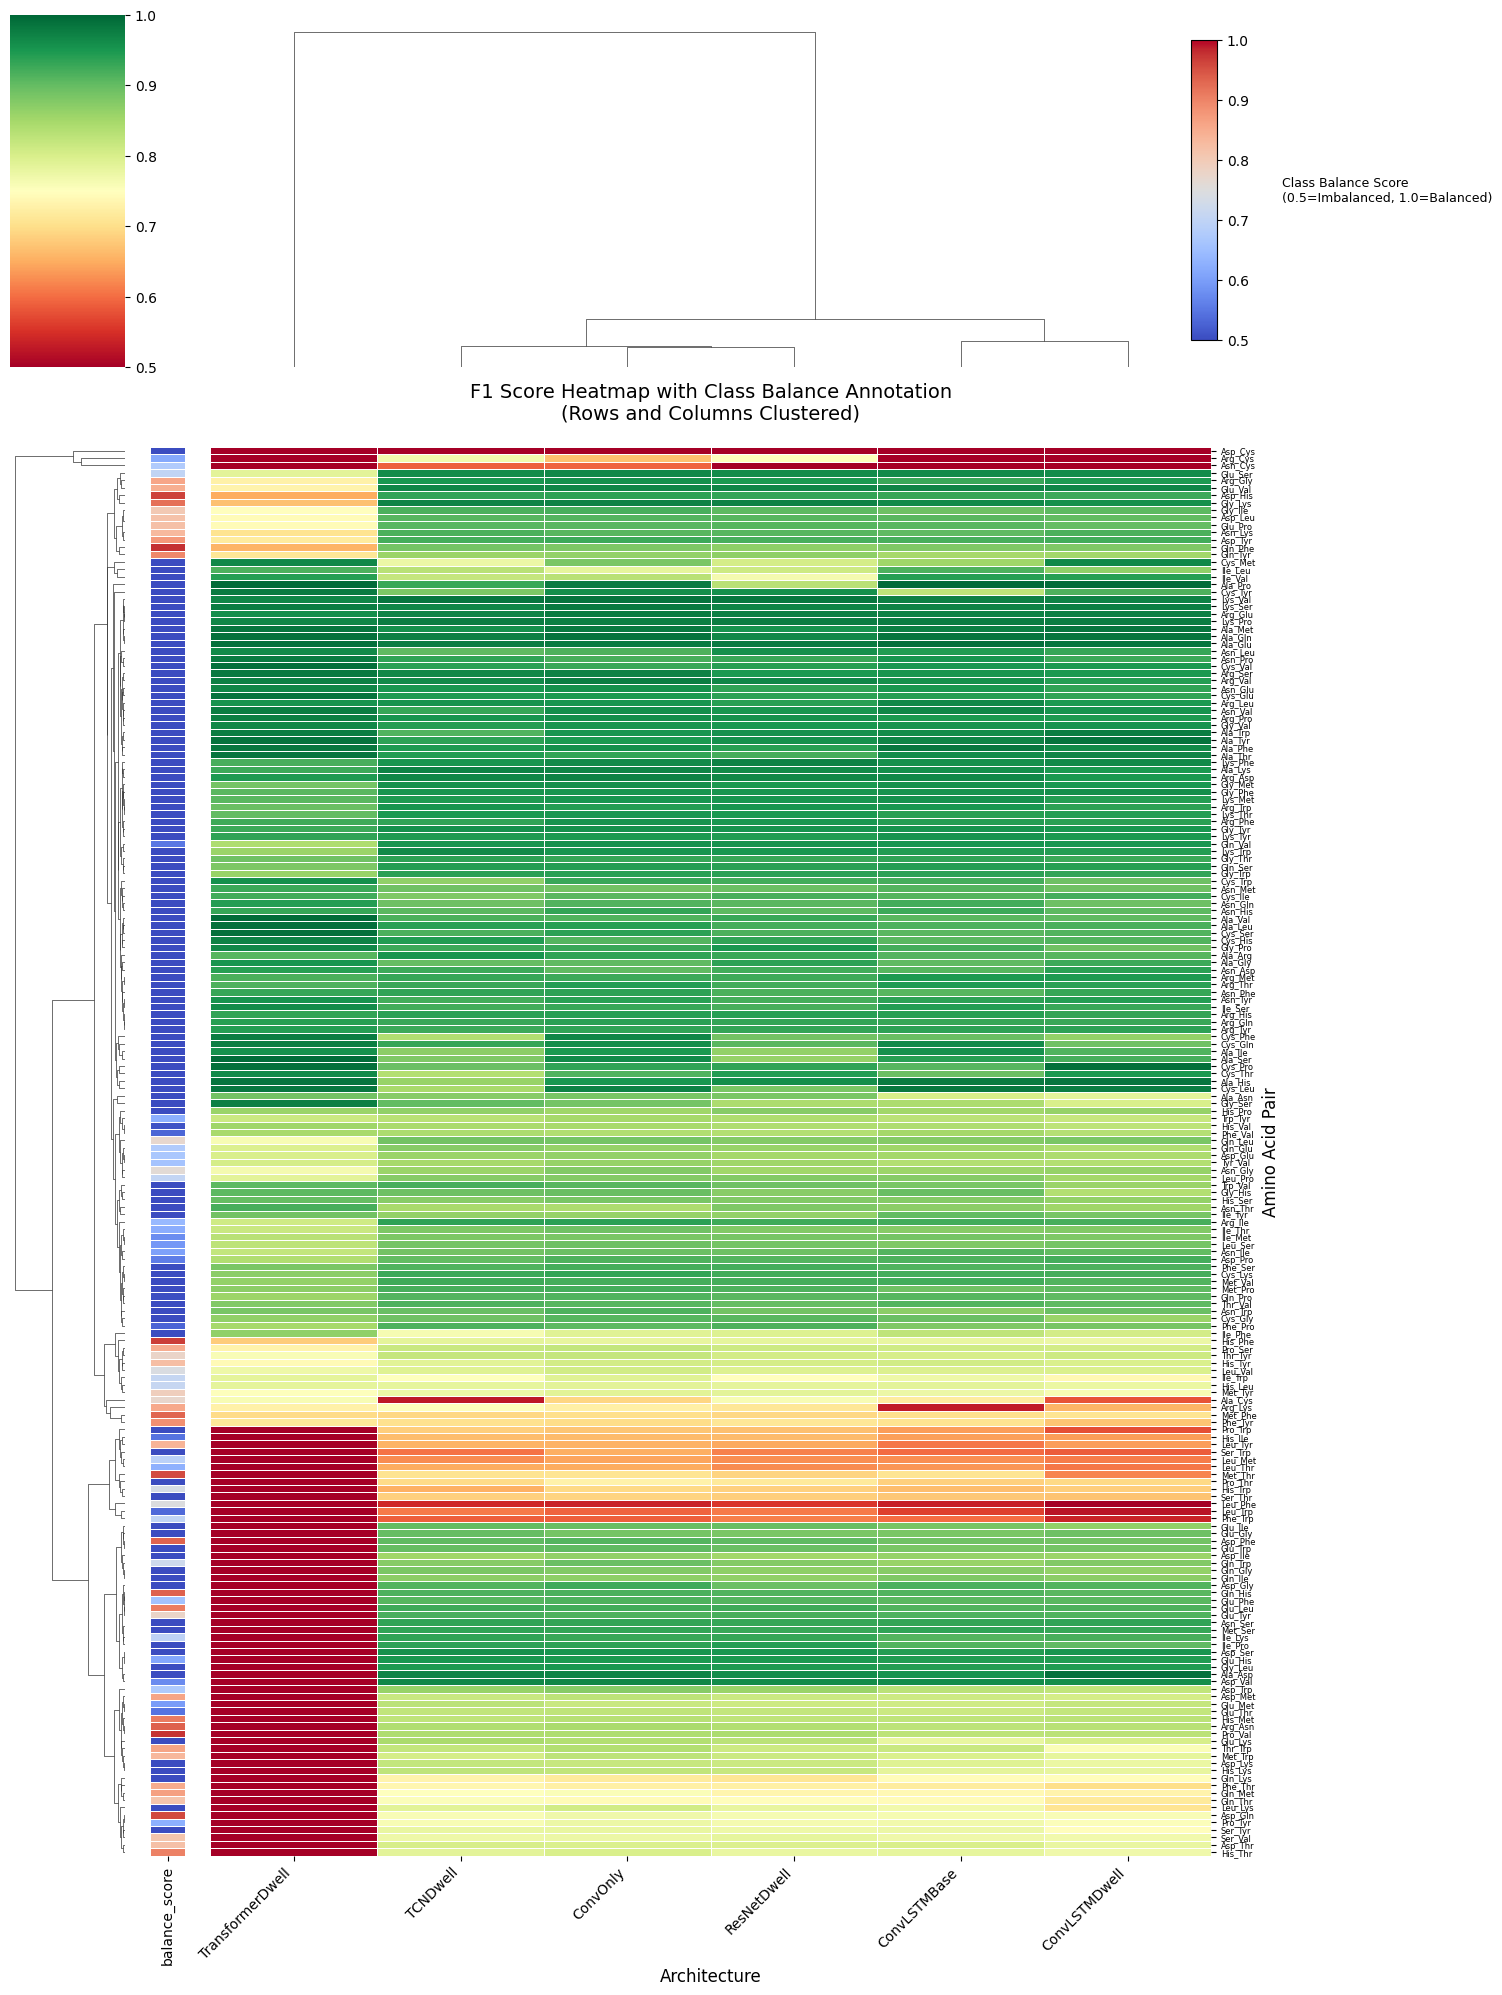


Heatmap dimensions: 190 pairs × 6 architectures
Row annotation shows class balance score (NOT clustered with F1 scores)


In [22]:
# Pivot data to create matrix: rows=pairs, cols=architectures, values=F1 scores
heatmap_data = df_pd.pivot(index="pair", columns="architecture", values="f1_mean")

# Map balance scores to colors using a colormap
# Use coolwarm: blue (low balance/imbalanced) to red (high balance/balanced)
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Create color mapping for class balance annotation
norm = Normalize(vmin=0.5, vmax=1.0)  # Balance score range
cmap_balance = cm.get_cmap("coolwarm")

# Map balance scores to colors for each pair in heatmap_data
balance_colors = row_colors_data.reindex(heatmap_data.index).map(lambda x: cmap_balance(norm(x)))

# Create clustered heatmap with class balance row annotation
plt.figure(figsize=(12, 20))
clustergrid = sns.clustermap(
    heatmap_data,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1.0,
    center=0.75,
    linewidths=0.5,
    figsize=(13, 20),  # Slightly wider to accommodate row colors
    dendrogram_ratio=(0.1, 0.2),
    cbar_pos=(0.02, 0.83, 0.03, 0.15),
    row_colors=balance_colors,  # Add class balance as row annotation
    xticklabels=True,
    yticklabels=True,
)

# Adjust labels
clustergrid.ax_heatmap.set_xlabel("Architecture", fontsize=12)
clustergrid.ax_heatmap.set_ylabel("Amino Acid Pair", fontsize=12)
clustergrid.ax_heatmap.set_title(
    "F1 Score Heatmap with Class Balance Annotation\n(Rows and Columns Clustered)",
    fontsize=14,
    pad=20
)

# Add legend for class balance color bar
# Create a ScalarMappable for the colorbar
from matplotlib.cm import ScalarMappable

sm = ScalarMappable(cmap=cmap_balance, norm=norm)
sm.set_array([])

# Add colorbar for class balance annotation
cbar_ax = clustergrid.fig.add_axes([0.92, 0.83, 0.02, 0.15])  # [left, bottom, width, height]
cbar = clustergrid.fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Class Balance Score\n(0.5=Imbalanced, 1.0=Balanced)',
               rotation=0, ha='left', va='center', fontsize=9, labelpad=10)
cbar.ax.yaxis.set_label_coords(3.5, 0.5)

# Rotate x-axis labels
plt.setp(clustergrid.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
plt.setp(clustergrid.ax_heatmap.get_yticklabels(), fontsize=6)

plt.tight_layout()
plt.show()

print(f"\nHeatmap dimensions: {heatmap_data.shape[0]} pairs × {heatmap_data.shape[1]} architectures")
print("Row annotation shows class balance score (NOT clustered with F1 scores)")

CORRELATION: CLASS BALANCE vs PERFORMANCE

Balance Score vs Average F1:
  Pearson r  = -0.4554 (p=4.0553e-11) ***
  Spearman ρ = -0.6183 (p=1.9950e-21) ***

Balance Score vs Average Accuracy:
  Pearson r  = -0.5870 (p=5.5722e-19) ***
  Spearman ρ = -0.5900 (p=3.3408e-19) ***

INTERPRETATION

⚠️  NEGATIVE correlation (r=-0.455): More balanced pairs perform WORSE
  → Unexpected pattern - balanced pairs are harder to distinguish
  → May indicate that class separation depends on class prevalence


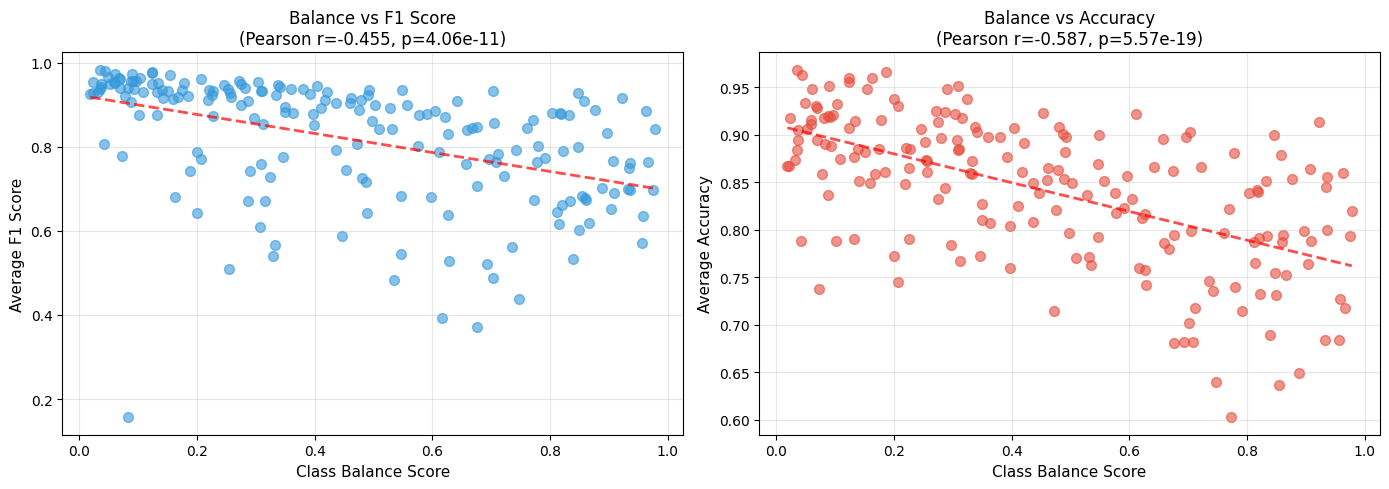


MOST IMBALANCED PAIRS - Performance Breakdown


GT(_tbl_data=      pair  balance_score    avg_f1  avg_accuracy
0  Ala_Ser       0.018943  0.926433      0.867217
1  Ala_Val       0.022507  0.927533      0.867550
2  Ala_Pro       0.022982  0.953500      0.917350
3  Cys_Ser       0.032406  0.930567      0.873000
4  Ala_Leu       0.034729  0.936883      0.883900
5  Ala_Glu       0.035567  0.983850      0.968633
6  Cys_Val       0.037186  0.948933      0.904750
7  Cys_Pro       0.037416  0.942383      0.894567
8  Ala_Asp       0.041860  0.807567      0.787750
9  Ala_Gln       0.043760  0.980567      0.962567, _body=<great_tables._gt_data.Body object at 0x1476302a5550>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='balance_score', type=<ColInfoTypeEnum.default: 1>, column_label='balance_score', column_align='right', column_width=None), ColInfo(var='avg_f1', type=<ColInfoTypeEnum.default: 1>, column_label='avg_f1', column_align='right', column_width=None), ColInfo(var='avg_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='avg_accuracy', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1476310c5ee0>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Most Imbalanced Pairs', subtitle='Do imbalanced pairs perform worse?', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x147631e18740>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x147631d8a3c0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='balance_score', rows=[0], mask=None), grpname=None, colname='balance_score', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[1], mask=None), grpname=None, colname='balance_score', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[2], mask=None), grpname=None, colname='balance_score', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[3], mask=None), grpname=None, colname='balance_score', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[4], mask=None), grpname=None, colname='balance_score', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[5], mask=None), grpname=None, colname='balance_score', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='balance_score', rows=[6], mask=None), grpname=None, colname='balance_score', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=

In [23]:
# Quantitative analysis: Correlation between class balance and performance
from scipy.stats import pearsonr, spearmanr

# Merge class balance with per-pair average performance
pair_perf_balance = pair_performance.join(
    class_balance_df.select(["pair", "balance_score"]),
    on="pair"
).to_pandas()

# Calculate correlations
pearson_f1, pearson_p = pearsonr(pair_perf_balance["balance_score"], pair_perf_balance["avg_f1"])
spearman_f1, spearman_p = spearmanr(pair_perf_balance["balance_score"], pair_perf_balance["avg_f1"])

pearson_acc, pearson_acc_p = pearsonr(pair_perf_balance["balance_score"], pair_perf_balance["avg_accuracy"])
spearman_acc, spearman_acc_p = spearmanr(pair_perf_balance["balance_score"], pair_perf_balance["avg_accuracy"])

print("=" * 80)
print("CORRELATION: CLASS BALANCE vs PERFORMANCE")
print("=" * 80)
print("\nBalance Score vs Average F1:")
print(f"  Pearson r  = {pearson_f1:+.4f} (p={pearson_p:.4e}) {'***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'ns'}")
print(f"  Spearman ρ = {spearman_f1:+.4f} (p={spearman_p:.4e}) {'***' if spearman_p < 0.001 else '**' if spearman_p < 0.01 else '*' if spearman_p < 0.05 else 'ns'}")

print("\nBalance Score vs Average Accuracy:")
print(f"  Pearson r  = {pearson_acc:+.4f} (p={pearson_acc_p:.4e}) {'***' if pearson_acc_p < 0.001 else '**' if pearson_acc_p < 0.01 else '*' if pearson_acc_p < 0.05 else 'ns'}")
print(f"  Spearman ρ = {spearman_acc:+.4f} (p={spearman_acc_p:.4e}) {'***' if spearman_acc_p < 0.001 else '**' if spearman_acc_p < 0.01 else '*' if spearman_acc_p < 0.05 else 'ns'}")

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

if abs(pearson_f1) < 0.1:
    print("\n✓ WEAK or NO correlation between class balance and F1 performance")
    print("  → Class imbalance does NOT significantly impact model performance")
    print("  → Models are robust to class imbalance in this dataset")
elif pearson_f1 > 0:
    print(f"\n⚠️  POSITIVE correlation (r={pearson_f1:.3f}): More balanced pairs perform BETTER")
    print("  → Class imbalance negatively impacts model performance")
    print("  → Consider class weighting or resampling for imbalanced pairs")
else:
    print(f"\n⚠️  NEGATIVE correlation (r={pearson_f1:.3f}): More balanced pairs perform WORSE")
    print("  → Unexpected pattern - balanced pairs are harder to distinguish")
    print("  → May indicate that class separation depends on class prevalence")

# Scatter plot: balance vs performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 vs Balance
axes[0].scatter(pair_perf_balance["balance_score"], pair_perf_balance["avg_f1"],
                alpha=0.6, s=50, color="#3498DB")
axes[0].set_xlabel("Class Balance Score", fontsize=11)
axes[0].set_ylabel("Average F1 Score", fontsize=11)
axes[0].set_title(f"Balance vs F1 Score\n(Pearson r={pearson_f1:+.3f}, p={pearson_p:.2e})", fontsize=12)
axes[0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(pair_perf_balance["balance_score"], pair_perf_balance["avg_f1"], 1)
p = np.poly1d(z)
x_line = np.linspace(pair_perf_balance["balance_score"].min(),
                      pair_perf_balance["balance_score"].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=2)

# Accuracy vs Balance
axes[1].scatter(pair_perf_balance["balance_score"], pair_perf_balance["avg_accuracy"],
                alpha=0.6, s=50, color="#E74C3C")
axes[1].set_xlabel("Class Balance Score", fontsize=11)
axes[1].set_ylabel("Average Accuracy", fontsize=11)
axes[1].set_title(f"Balance vs Accuracy\n(Pearson r={pearson_acc:+.3f}, p={pearson_acc_p:.2e})", fontsize=12)
axes[1].grid(alpha=0.3)

# Add trend line
z2 = np.polyfit(pair_perf_balance["balance_score"], pair_perf_balance["avg_accuracy"], 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), "r--", alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

# Show most imbalanced pairs with their performance
print("\n" + "=" * 80)
print("MOST IMBALANCED PAIRS - Performance Breakdown")
print("=" * 80)

most_imbalanced = pair_perf_balance.sort_values("balance_score").head(10).reset_index(drop=True)
(
    GT(most_imbalanced[["pair", "balance_score", "avg_f1", "avg_accuracy"]])
    .tab_header(
        title="Top 10 Most Imbalanced Pairs",
        subtitle="Do imbalanced pairs perform worse?"
    )
    .fmt_number(columns=["balance_score", "avg_f1", "avg_accuracy"], decimals=4)
    .data_color(
        columns=["balance_score"],
        palette=["#a50f15", "#fee5d9"],
        domain=[0.5, 1.0]
    )
    .data_color(
        columns=["avg_f1"],
        palette=["#fee5d9", "#31a354"],
        domain=[0.5, 1.0]
    )
)

**Interpretation: Class Balance Impact on Performance**

The colored bar on the left of the heatmap shows the class balance score for each amino acid pair:
- **Blue** = Highly imbalanced (balance score ~0.5, one class dominates)
- **White** = Moderately balanced (balance score ~0.75)
- **Red** = Well balanced (balance score ~1.0, classes are equal)

**Key Questions to Investigate:**
1. **Do imbalanced pairs cluster together?** If blue rows cluster in the dendrogram, it suggests imbalance creates a distinct performance signature.
2. **Do imbalanced pairs perform worse?** Look for correlation between blue color and low F1 scores (yellow/red cells in the heatmap).
3. **Are certain architectures more robust to imbalance?** Compare columns - do some architectures maintain high F1 (green) even for imbalanced pairs (blue)?

**Note:** The class balance annotation is **not** included in the hierarchical clustering - it's overlaid for visual analysis only. The clustering is based solely on F1 score patterns across architectures.

### 2. Consistency Metrics

Quantify consistency and robustness in two ways:

**A. Per AA Pair Metrics** - Which pairs are hardest and which show most variable performance?
- **Mean F1**: Average performance across all architectures
- **Std F1**: Standard deviation (absolute variability)
- **CV (Coefficient of Variation)**: Std/Mean (relative variability)
- **Difficulty Score**: 1 - Mean F1 (higher = harder pair)
- **Consensus Score**: 1 - CV (higher = all architectures agree)

**B. Per Architecture Metrics** - Which architectures are most robust?
- **Mean F1**: Average performance across all pairs
- **Std F1**: Standard deviation across pairs
- **Robustness Score**: 1 / (1 + Std) (higher = more consistent across different pair types)

In [24]:
# A. Per AA Pair Consistency Metrics
pair_consistency = (
    df.group_by("pair")
    .agg(
        [
            pl.col("f1_mean").mean().alias("mean_f1"),
            pl.col("f1_mean").std().alias("std_f1"),
        ]
    )
    .with_columns(
        [
            (pl.col("std_f1") / pl.col("mean_f1")).alias("cv"),
            (1 - pl.col("mean_f1")).alias("difficulty_score"),
            (1 - (pl.col("std_f1") / pl.col("mean_f1"))).alias("consensus_score"),
        ]
    )
)

# Sort by different criteria to show extremes
print("=" * 80)
print("A. PER AA PAIR CONSISTENCY METRICS")
print("=" * 80)

print("\n--- Top 10 HARDEST Pairs (highest difficulty score) ---")
hardest_pairs = pair_consistency.sort("difficulty_score", descending=True).head(10)
(
    GT(hardest_pairs)
    .tab_header(
        title="Top 10 Hardest Pairs",
        subtitle="Highest difficulty score (1 - mean F1)"
    )
    .fmt_number(columns=["mean_f1", "std_f1", "cv", "difficulty_score", "consensus_score"], decimals=4)
    .data_color(
        columns=["difficulty_score"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.0, 1.0]
    )
)

print("\n--- Top 10 MOST VARIABLE Pairs (highest CV - architectures disagree most) ---")
most_variable_pairs = pair_consistency.sort("cv", descending=True).head(10)
(
    GT(most_variable_pairs)
    .tab_header(
        title="Top 10 Most Variable Pairs",
        subtitle="Highest coefficient of variation - architectures disagree most"
    )
    .fmt_number(columns=["mean_f1", "std_f1", "cv", "difficulty_score", "consensus_score"], decimals=4)
    .data_color(
        columns=["cv"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.0, 1.0]
    )
)

print("\n--- Top 10 MOST CONSISTENT Pairs (lowest CV - all architectures agree) ---")
most_consistent_pairs = pair_consistency.sort("cv").head(10)
(
    GT(most_consistent_pairs)
    .tab_header(
        title="Top 10 Most Consistent Pairs",
        subtitle="Lowest coefficient of variation - all architectures agree"
    )
    .fmt_number(columns=["mean_f1", "std_f1", "cv", "difficulty_score", "consensus_score"], decimals=4)
    .data_color(
        columns=["consensus_score"],
        palette=["#fee5d9", "#31a354"],
        domain=[0.9, 1.0]
    )
)

print("\n--- Top 10 EASIEST Pairs (lowest difficulty score) ---")
easiest_pairs = pair_consistency.sort("difficulty_score").head(10)
(
    GT(easiest_pairs)
    .tab_header(
        title="Top 10 Easiest Pairs",
        subtitle="Lowest difficulty score (highest mean F1)"
    )
    .fmt_number(columns=["mean_f1", "std_f1", "cv", "difficulty_score", "consensus_score"], decimals=4)
    .data_color(
        columns=["mean_f1"],
        palette=["#fee5d9", "#31a354"],
        domain=[0.8, 1.0]
    )
)

A. PER AA PAIR CONSISTENCY METRICS

--- Top 10 HARDEST Pairs (highest difficulty score) ---

--- Top 10 MOST VARIABLE Pairs (highest CV - architectures disagree most) ---

--- Top 10 MOST CONSISTENT Pairs (lowest CV - all architectures agree) ---

--- Top 10 EASIEST Pairs (lowest difficulty score) ---


GT(_tbl_data=shape: (10, 6)
┌─────────┬──────────┬──────────┬──────────┬──────────────────┬─────────────────┐
│ pair    ┆ mean_f1  ┆ std_f1   ┆ cv       ┆ difficulty_score ┆ consensus_score │
│ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---              ┆ ---             │
│ str     ┆ f64      ┆ f64      ┆ f64      ┆ f64              ┆ f64             │
╞═════════╪══════════╪══════════╪══════════╪══════════════════╪═════════════════╡
│ Ala_Glu ┆ 0.98385  ┆ 0.006106 ┆ 0.006206 ┆ 0.01615          ┆ 0.993794        │
│ Ala_Gln ┆ 0.980567 ┆ 0.009469 ┆ 0.009657 ┆ 0.019433         ┆ 0.990343        │
│ Lys_Val ┆ 0.9785   ┆ 0.007748 ┆ 0.007918 ┆ 0.0215           ┆ 0.992082        │
│ Lys_Pro ┆ 0.976067 ┆ 0.003916 ┆ 0.004012 ┆ 0.023933         ┆ 0.995988        │
│ Lys_Ser ┆ 0.97385  ┆ 0.005209 ┆ 0.005349 ┆ 0.02615          ┆ 0.994651        │
│ Ala_Met ┆ 0.973067 ┆ 0.013382 ┆ 0.013752 ┆ 0.026933         ┆ 0.986248        │
│ Arg_Glu ┆ 0.971567 ┆ 0.006515 ┆ 0.006706 ┆ 0.028433         ┆ 0.993294        │
│ Ala_Tyr ┆ 0.9649   ┆ 0.020611 ┆ 0.021361 ┆ 0.0351           ┆ 0.978639        │
│ Arg_Val ┆ 0.963617 ┆ 0.01224  ┆ 0.012702 ┆ 0.036383         ┆ 0.987298        │
│ Ala_Phe ┆ 0.96285  ┆ 0.018134 ┆ 0.018834 ┆ 0.03715          ┆ 0.981166        │
└─────────┴──────────┴──────────┴──────────┴──────────────────┴─────────────────┘, _body=<great_tables._gt_data.Body object at 0x14766094a4e0>, _boxhead=Boxhead([ColInfo(var='pair', type=<ColInfoTypeEnum.default: 1>, column_label='pair', column_align='left', column_width=None), ColInfo(var='mean_f1', type=<ColInfoTypeEnum.default: 1>, column_label='mean_f1', column_align='right', column_width=None), ColInfo(var='std_f1', type=<ColInfoTypeEnum.default: 1>, column_label='std_f1', column_align='right', column_width=None), ColInfo(var='cv', type=<ColInfoTypeEnum.default: 1>, column_label='cv', column_align='right', column_width=None), ColInfo(var='difficulty_score', type=<ColInfoTypeEnum.default: 1>, column_label='difficulty_score', column_align='right', column_width=None), ColInfo(var='consensus_score', type=<ColInfoTypeEnum.default: 1>, column_label='consensus_score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14763124cda0>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Easiest Pairs', subtitle='Lowest difficulty score (highest mean F1)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1476ede34680>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1476ede351f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='mean_f1', rows=[0], mask=None), grpname=None, colname='mean_f1', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#42a85f')]), StyleInfo(locname=LocBody(columns='mean_f1', rows=[1], mask=None), grpname=None, colname='mean_f1', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#45a961')]), StyleInfo(locname=LocBody(columns='mean_f1', rows=[2], mask=None), grpname=None, colname='mean_f1', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#47aa62')]), StyleInfo(locname=LocBody(columns='mean_f1', rows=[3], mask=None), grpname=None, colname='mean_f1', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#4aab64')]), StyleInfo(locname=LocBody(columns='mean_f1', rows=[4], mask=None), grpna

In [25]:
# B. Per Architecture Consistency Metrics
arch_consistency = (
    df.group_by("architecture")
    .agg(
        [
            pl.col("f1_mean").mean().alias("mean_f1"),
            pl.col("f1_mean").std().alias("std_f1"),
            pl.col("f1_mean").min().alias("min_f1"),
            pl.col("f1_mean").max().alias("max_f1"),
            pl.count().alias("n_pairs"),
        ]
    )
    .with_columns(
        [
            (1 / (1 + pl.col("std_f1"))).alias("robustness_score"),
            (pl.col("max_f1") - pl.col("min_f1")).alias("range_f1"),
        ]
    )
    .sort("mean_f1", descending=True)
)

print("\n" + "=" * 80)
print("B. PER ARCHITECTURE CONSISTENCY METRICS")
print("=" * 80)
print("\nRanked by mean F1 (with robustness metrics):")
print("Higher robustness_score = more consistent across different pair types\n")

(
    GT(arch_consistency)
    .tab_header(
        title="Per Architecture Consistency Metrics",
        subtitle="Higher robustness score = more consistent across different pair types"
    )
    .fmt_number(
        columns=["mean_f1", "std_f1", "min_f1", "max_f1", "robustness_score", "range_f1"],
        decimals=4
    )
    .data_color(
        columns=["mean_f1"],
        palette=["#fee5d9", "#a50f15"],
        domain=[0.5, 1.0]
    )
    .data_color(
        columns=["robustness_score"],
        palette=["#fee5d9", "#31a354"],
        domain=[0.7, 1.0]
    )
)

# Highlight most robust architecture
most_robust = arch_consistency.sort("robustness_score", descending=True).head(1)
print("\n🏆 Most ROBUST architecture (lowest variance across pairs):")
print(f"   {most_robust['architecture'][0]} (robustness score: {most_robust['robustness_score'][0]:.4f})")

# Highlight best performing architecture
best_overall = arch_consistency.sort("mean_f1", descending=True).head(1)
print("\n🏆 BEST OVERALL architecture (highest mean F1):")
print(f"   {best_overall['architecture'][0]} (mean F1: {best_overall['mean_f1'][0]:.4f})")


B. PER ARCHITECTURE CONSISTENCY METRICS

Ranked by mean F1 (with robustness metrics):
Higher robustness_score = more consistent across different pair types


🏆 Most ROBUST architecture (lowest variance across pairs):
   TCNDwell (robustness score: 0.9073)

🏆 BEST OVERALL architecture (highest mean F1):
   ConvOnly (mean F1: 0.8742)


### 3. Two-Way ANOVA: Variance Decomposition

Two-way ANOVA decomposes the total variance in F1 scores into components:

1. **Architecture (main effect)**: How much variance is explained by which architecture is used?
2. **AA Pair (main effect)**: How much variance is explained by which pair is being classified?
3. **Architecture × Pair Interaction**: Are there specialization effects where certain architectures excel at specific pairs?

**Interpretation:**
- Large Architecture effect → Choice of architecture matters a lot
- Large Pair effect → Some pairs are universally harder/easier
- Large Interaction effect → Specialization exists (specific architectures excel at specific pair types)
- Compare effect sizes (eta-squared, ω²) to understand relative importance

In [ ]:
# Perform two-way ANOVA
# Check if statsmodels is available, if not use scipy for simpler one-way tests
try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm

    # Prepare data for ANOVA - filter out any NaN or Inf values
    anova_data = df_pd[["architecture", "pair", "f1_mean"]].copy()

    # Check for and report any problematic values
    n_total = len(anova_data)
    anova_data = anova_data[np.isfinite(anova_data["f1_mean"])]
    n_valid = len(anova_data)

    if n_valid < n_total:
        print(f"Note: Removed {n_total - n_valid} rows with non-finite F1 values")

    print("=" * 80)
    print("TWO-WAY ANOVA: F1 ~ Architecture + Pair (Main Effects Only)")
    print("=" * 80)
    print(f"\nAnalyzing {n_valid} valid observations")
    print("Note: Interaction term excluded due to model complexity (190 pairs × 6 architectures)")

    # Fit the model WITHOUT interaction term (too many parameters cause numerical issues)
    model = ols("f1_mean ~ C(architecture) + C(pair)", data=anova_data).fit()
    anova_table = anova_lm(model, typ=2)

    # Check if the model fit was successful
    if len(anova_table) < 2 or not all(np.isfinite(anova_table['sum_sq'])):
        raise ValueError("Model fit produced invalid results")

    # Calculate effect sizes (eta-squared)
    anova_table["eta_sq"] = anova_table["sum_sq"] / anova_table["sum_sq"].sum()

    # Calculate omega-squared (more conservative effect size)
    if "Residual" in anova_table.index:
        ms_error = anova_table.loc["Residual", "sum_sq"] / anova_table.loc["Residual", "df"]
        n = len(anova_data)

        def calc_omega_sq(row):
            if row.name == "Residual":
                return np.nan
            df_effect = row["df"]
            ss_effect = row["sum_sq"]
            omega_sq = (ss_effect - df_effect * ms_error) / (anova_table["sum_sq"].sum() + ms_error)
            return max(0, omega_sq)  # omega-squared can't be negative

        anova_table["omega_sq"] = anova_table.apply(calc_omega_sq, axis=1)
    else:
        anova_table["omega_sq"] = np.nan

    # Prepare table for display
    anova_table_display = anova_table.reset_index()
    anova_table_display.columns = ["Source", "Sum_Sq", "DF", "F", "P_value", "eta_sq", "omega_sq"]

    print("\nANOVA Table:")
    (
        GT(anova_table_display)
        .tab_header(
            title="Two-Way ANOVA Results (Main Effects)",
            subtitle="F1 ~ Architecture + Pair"
        )
        .fmt_number(columns=["Sum_Sq", "F"], decimals=2)
        .fmt_number(columns=["eta_sq", "omega_sq"], decimals=4)
        .fmt_scientific(columns=["P_value"], decimals=2)
        .data_color(
            columns=["eta_sq"],
            palette=["#fee5d9", "#a50f15"],
            domain=[0.0, 0.5]
        )
    )

    # Interpretation
    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)

    arch_eta = anova_table.loc["C(architecture)", "eta_sq"]
    pair_eta = anova_table.loc["C(pair)", "eta_sq"]

    print("\nVariance Explained (η²):")
    print(f"  Architecture:  {arch_eta*100:5.2f}% - {'SMALL' if arch_eta < 0.06 else 'MEDIUM' if arch_eta < 0.14 else 'LARGE'} effect")
    print(f"  AA Pair:       {pair_eta*100:5.2f}% - {'SMALL' if pair_eta < 0.06 else 'MEDIUM' if pair_eta < 0.14 else 'LARGE'} effect")

    print("\n📊 Key Findings:")
    effects = {
        "Architecture choice": arch_eta,
        "AA pair difficulty": pair_eta,
    }
    sorted_effects = sorted(effects.items(), key=lambda x: x[1], reverse=True)

    print(f"  1. {sorted_effects[0][0]} explains the MOST variance ({sorted_effects[0][1]*100:.1f}%)")
    print(f"  2. {sorted_effects[1][0]} explains less variance ({sorted_effects[1][1]*100:.1f}%)")

    # Estimate interaction effect from residual variance
    if "Residual" in anova_table.index:
        residual_eta = anova_table.loc["Residual", "eta_sq"]
        print(f"\n  Residual (unexplained):  {residual_eta*100:5.2f}%")
        print("  ↳ This includes Architecture×Pair interactions + random error")

    if arch_eta > pair_eta:
        print("\n✓ Architecture choice is MORE important than pair difficulty")
        print("  → Focus on selecting the right architecture")
        print("  → Architecture rankings are meaningful across pairs")
    else:
        print("\n✓ Pair difficulty is MORE important than architecture choice")
        print("  → Some pairs are inherently harder regardless of architecture")
        print("  → Consider pair-specific analysis")

    statsmodels_available = True

except (ImportError, KeyError, ValueError) as e:
    if isinstance(e, ImportError):
        print("statsmodels not available - performing simplified one-way ANOVAs instead")
        print("Install statsmodels for full two-way ANOVA: pip install statsmodels")
    else:
        print(f"\n⚠️  ANOVA failed with error: {type(e).__name__}: {e}")
        print("\nFalling back to simplified one-way ANOVAs...")

    # Simplified analysis with scipy
    print("\n" + "=" * 80)
    print("SIMPLIFIED VARIANCE ANALYSIS (scipy)")
    print("=" * 80)

    # Filter valid data
    valid_data = df_pd[np.isfinite(df_pd["f1_mean"])].copy()

    # One-way ANOVA for architecture
    arch_groups = [group["f1_mean"].values for name, group in valid_data.groupby("architecture")]
    if len(arch_groups) > 1:
        f_arch, p_arch = stats.f_oneway(*arch_groups)
        print(f"\nArchitecture effect: F={f_arch:.2f}, p={p_arch:.4e}")

        # Calculate eta-squared for architecture
        ss_between_arch = sum([len(g) * (g.mean() - valid_data["f1_mean"].mean())**2 for g in arch_groups])
        ss_total = sum([(x - valid_data["f1_mean"].mean())**2 for x in valid_data["f1_mean"]])
        eta_sq_arch = ss_between_arch / ss_total
        print(f"  η² (Architecture) = {eta_sq_arch:.4f} ({eta_sq_arch*100:.2f}% variance explained)")

    # One-way ANOVA for pair
    pair_groups = [group["f1_mean"].values for name, group in valid_data.groupby("pair")]
    if len(pair_groups) > 1:
        f_pair, p_pair = stats.f_oneway(*pair_groups)
        print(f"\nAA Pair effect: F={f_pair:.2f}, p={p_pair:.4e}")

        # Calculate eta-squared for pair
        ss_between_pair = sum([len(g) * (g.mean() - valid_data["f1_mean"].mean())**2 for g in pair_groups])
        eta_sq_pair = ss_between_pair / ss_total
        print(f"  η² (AA Pair) = {eta_sq_pair:.4f} ({eta_sq_pair*100:.2f}% variance explained)")

    print("\n" + "=" * 80)
    print("INTERPRETATION (from one-way ANOVAs)")
    print("=" * 80)

    if 'eta_sq_arch' in locals() and 'eta_sq_pair' in locals():
        print(f"\nVariance Explained (η²):")
        print(f"  Architecture:  {eta_sq_arch*100:5.2f}% - {'SMALL' if eta_sq_arch < 0.06 else 'MEDIUM' if eta_sq_arch < 0.14 else 'LARGE'} effect")
        print(f"  AA Pair:       {eta_sq_pair*100:5.2f}% - {'SMALL' if eta_sq_pair < 0.06 else 'MEDIUM' if eta_sq_pair < 0.14 else 'LARGE'} effect")

        print("\n⚠️  Note: These estimates are UPPER BOUNDS from separate one-way ANOVAs")
        print("   They don't account for the overlap between architecture and pair effects")

        if eta_sq_arch > eta_sq_pair:
            print("\n✓ Architecture choice appears MORE important than pair difficulty")
        else:
            print("\n✓ Pair difficulty appears MORE important than architecture choice")

    print("\nNote: Install statsmodels for full two-way ANOVA with proper effect decomposition")
    statsmodels_available = False

TWO-WAY ANOVA: F1 ~ Architecture + Pair (Main Effects Only)

Analyzing 1140 valid observations
Note: Interaction term excluded due to model complexity (190 pairs × 6 architectures)

ANOVA Table:

INTERPRETATION

Variance Explained (η²):
  Architecture:  19.19% - LARGE effect
  AA Pair:       41.22% - LARGE effect

📊 Key Findings:
  1. AA pair difficulty explains the MOST variance (41.2%)
  2. Architecture choice explains less variance (19.2%)

  Residual (unexplained):  39.58%
  ↳ This includes Architecture×Pair interactions + random error

✓ Pair difficulty is MORE important than architecture choice
  → Some pairs are inherently harder regardless of architecture
  → Consider pair-specific analysis


### Summary: Tier 1 Analysis Insights

The three analyses above provide complementary views of the model comparison results:

1. **Clustered Heatmap** → Visual identification of performance patterns and natural groupings
2. **Consistency Metrics** → Quantitative measures of pair difficulty and architecture robustness
3. **Two-Way ANOVA** → Statistical decomposition showing whether variance is driven by architecture, pairs, or interactions

**Next Steps (Future Analyses):**
- **Tier 2**: Architecture specialization analysis, pairwise correlations
- **Tier 3**: Chemical property enrichment, distance-performance relationships
- **Tier 4**: PCA/dimensionality reduction, predictive modeling

See Issue #72 for full analysis roadmap.